# MLS-SRTP Figures

This notebook generates figures from the Criterion benchmark results.

## Prerequisites: 

Run the benchmarks:
```bash
./REPRODUCE.sh
```

Or run individual benchmarks manually, for example:
```bash
cargo bench --package safecast-core --bench srtp_throughput_criterion
```

In [159]:
import json
import os
import re
from pathlib import Path

# to make sure re-running the notebook does not mark every
# figure file as modified in git
os.environ['SOURCE_DATE_EPOCH'] = '0'

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Global matplotlib style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'legend.fontsize': 9,
    'legend.frameon': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '-',
    'grid.color': '#d0d0d0',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.9,
    'axes.edgecolor': '#444444',
    'xtick.color': '#444444',
    'ytick.color': '#444444',
    'axes.labelcolor': '#222222',
    'text.color': '#222222',
    'lines.markeredgecolor': 'white',
    'lines.markeredgewidth': 1.0,
})

# All Criterion results are copied here by REPRODUCE.sh
CRITERION_DIR = Path('benches/results/criterion')

# SRTP throughput (encrypt/decrypt across 15 payload sizes)
RESULTS_DIR = CRITERION_DIR / 'srtp_throughput' / 'protect'
UNPROTECT_RESULTS_DIR = CRITERION_DIR / 'srtp_throughput' / 'unprotect'

# PEP throughput (CTR and CTR_CMAC-64 modes, encrypt/decrypt)
PEP_DIR = CRITERION_DIR / 'pep_throughput'

# MLS rekey (sender/receiver pipeline across group sizes)
REKEY_DIR = CRITERION_DIR / 'rekey'

# MLS rekey breakdown (component-level measurements)
REKEY_BREAKDOWN_DIR = CRITERION_DIR / 'rekey_breakdown'

# Key derivation (MLS export + SRTP KDF)
KEY_DERIVATION_DIR = CRITERION_DIR / 'key_derivation'

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

In [160]:
def load_criterion_results(results_dir: Path) -> dict:
    """Loads Criterion benchmark results from a directory of payload-size subdirs.
    
    Returns a dict mapping payload_size (int) -> {
        'label': str, 'payload_bytes': int, 'packet_bytes': int,
        'mean_ns': float, 'std_ns': float, 'throughput_gbps': float
    }
    """
    results = {}
    
    for entry in sorted(results_dir.iterdir()):
        
        # skipping the top-level "report/" folder (Criterion's summary HTML)
        if not entry.is_dir() or entry.name == 'report':
            continue
        
        # each benchmark run has benchmark.json (metadata) and estimates.json (stats)
        bench_path = entry / 'new' / 'benchmark.json'
        est_path = entry / 'new' / 'estimates.json'
        
        if not bench_path.exists() or not est_path.exists():
            continue
        
        with open(bench_path) as f:
            bench = json.load(f)
        with open(est_path) as f:
            estimates = json.load(f)
        
        label = bench['value_str']
        
        # criterion's "Bytes" throughput field = total packet size on the wire
        # (for SRTP: 12 B RTP header + payload + 16 B GCM tag)
        # (for PEP CTR: 12 B RTP header + payload)
        # (for PEP CTR+CMAC: 12 B RTP header + payload + 8 B CMAC tag)
        packet_bytes = bench['throughput']['Bytes']
        
        mean_ns = estimates['mean']['point_estimate']
        std_ns = estimates['std_dev']['point_estimate']
        
        # extracting the numeric payload size from the label 
        # (e.g. "1424B_standard" -> 1424)
        match = re.match(r'(\d+)B', label)
        if match:
            payload_size = int(match.group(1))
        else:
            continue
        
        # bits/ns = Gbps (since 1 bit/ns = 1 Gbps)
        throughput_gbps = (packet_bytes * 8) / mean_ns
        
        results[payload_size] = {
            'label': label,
            'payload_bytes': payload_size,
            'packet_bytes': packet_bytes,
            'mean_ns': mean_ns,
            'std_ns': std_ns,
            'throughput_gbps': throughput_gbps,
        }
    
    # sorting by payload size
    return dict(sorted(results.items()))


results = load_criterion_results(RESULTS_DIR)

print(f'Loaded {len(results)} benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       102.4        3.44 Gbps
     32B       106.1        4.52 Gbps
     40B       112.4        4.84 Gbps
     64B       109.6        6.71 Gbps
    128B       118.7       10.51 Gbps
    160B       127.4       11.80 Gbps
    256B       145.4       15.62 Gbps
    512B       158.5       27.25 Gbps
    800B       186.0       35.60 Gbps
   1024B       211.5       39.80 Gbps
   1200B       230.3       42.66 Gbps
   1424B       252.2       46.06 Gbps
   2048B       317.8       52.26 Gbps
   4096B       530.3       62.21 Gbps
   8924B      1038.4       68.97 Gbps


In [161]:
# Loading decryption (unprotect) results using the same loader function
unprotect_results = load_criterion_results(UNPROTECT_RESULTS_DIR)

print(f'Loaded {len(unprotect_results)} unprotect benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in unprotect_results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 unprotect benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       126.9        2.77 Gbps
     32B       126.8        3.79 Gbps
     40B       132.1        4.12 Gbps
     64B       127.6        5.77 Gbps
    128B       137.0        9.11 Gbps
    160B       144.5       10.41 Gbps
    256B       161.6       14.06 Gbps
    512B       197.1       21.92 Gbps
    800B       227.0       29.18 Gbps
   1024B       242.6       34.69 Gbps
   1200B       267.5       36.72 Gbps
   1424B       294.3       39.47 Gbps
   2048B       352.8       47.07 Gbps
   4096B       574.7       57.40 Gbps
   8924B      1179.6       60.71 Gbps


## Figure 1: SRTP Throughput vs. Uncompressed Video Bitrates

Throughput (Gbps) for SRTP `protect()` (encrypt) and `unprotect()` (decrypt)
across 15 payload sizes. Both operations are pure crypto (no network or
packet construction overhead). Reference lines show uncompressed video
bitrates (ST 2110, 4:2:2, 10-bit).

Data from Criterion results in `criterion/srtp_throughput/`.

In [162]:
# --- Uncompressed video bitrates (ST 2110, 4:2:2, 10-bit) ---
# These are reference bitrates for uncompressed ST 2110 video formats.
# They are used as horizontal reference lines in the throughput plot 
# to show how SRTP compares to real workloads.

video_formats = [
    # (label,       bitrate_gbps, resolution_group)
    ('720p50',       0.96,  '720p'),
    ('720p60',       1.15,  '720p'),
    ('1080p50',      2.15,  '1080p'),
    ('1080p60',      2.58,  '1080p'),
    ('2160p50',      8.60,  '2160p'),
    ('2160p60',     10.32,  '2160p'),
    ('2160p120',    20.65,  '2160p'),
    ('2160p300',    51.62,  '2160p'),
    ('4320p50',     34.41,  '4320p'),
    ('4320p60',     41.29,  '4320p'),
]

# Color scheme by resolution family
resolution_colors = {
    '720p':  '#009E73',
    '1080p': '#56B4E9',
    '2160p': '#E69F00',
    '4320p': '#CC79A7',
}

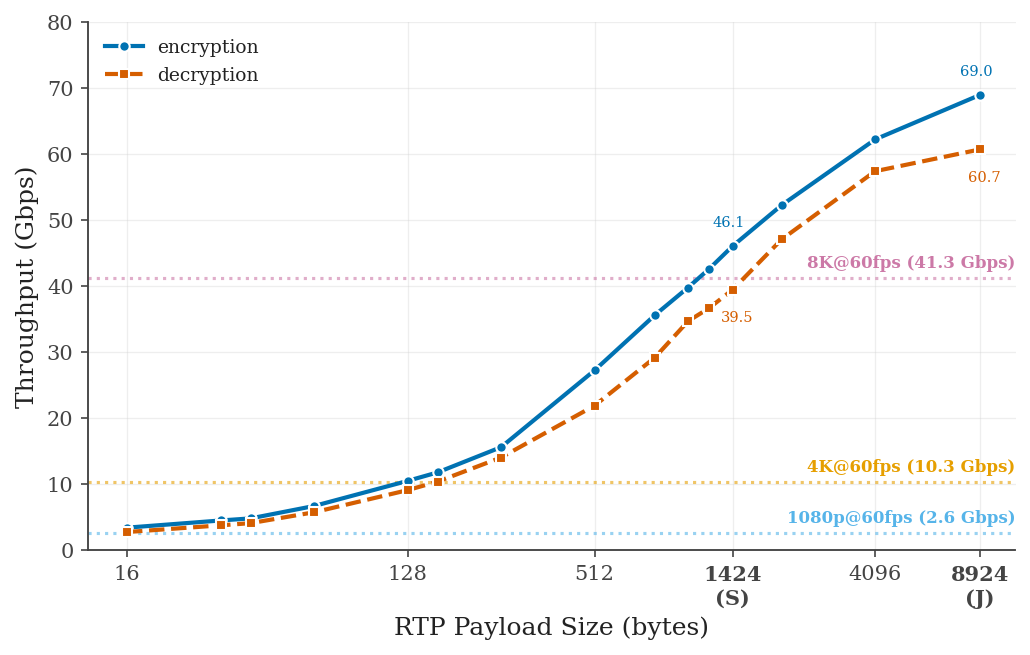

In [163]:
# Extracting sorted payload sizes and corresponding throughputs 
# from benchmark results
payload_sizes = np.array(list(results.keys()))
throughput_gbps = np.array([r['throughput_gbps'] for r in results.values()])

# decrypt throughput (same payload sizes since both benchmarks use same set)
unprotect_payload_sizes = np.array(list(unprotect_results.keys()))
unprotect_throughput_gbps = np.array([r['throughput_gbps'] for r in unprotect_results.values()])

fig, ax = plt.subplots(figsize=(7, 4.5))

# --- SRTP throughput curves ---
ax.plot(payload_sizes, throughput_gbps, 'o-', color='#0072B2', linewidth=2,
        markersize=5, zorder=5, label='encryption')
ax.plot(unprotect_payload_sizes, unprotect_throughput_gbps, 's--', color='#D55E00',
        linewidth=2, markersize=5, zorder=5, label='decryption')

# --- Value labels at the two MTU sizes ---
# encrypt above, decrypt below, consistent 8pt offset, colors match lines
pt_off = 10
for sz in [1424, 8924]:
    tp_enc = results[sz]['throughput_gbps']
    ax.annotate(f'{tp_enc:.1f}', (sz, tp_enc),
                textcoords='offset points', xytext=(-2, pt_off - 2),
                fontsize=7, ha='center', va='bottom', color='#0072B2')
    tp_dec = unprotect_results[sz]['throughput_gbps']
    ax.annotate(f'{tp_dec:.1f}', (sz, tp_dec),
                textcoords='offset points', xytext=(+2, -pt_off),
                fontsize=7, ha='center', va='top', color='#D55E00')

# --- Video bitrate reference lines ---
y_max = 80

display_formats = {
    '1080p60': '1080p',
    '2160p60': '4K',
    '4320p60': '8K',
}

for label, bitrate, res_group in video_formats:
    if label not in display_formats:
        continue
    display_label = display_formats[label]
    color = resolution_colors[res_group]
    ax.axhline(y=bitrate, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    ax.text(1.0, bitrate + 1.0, f'{display_label}@60fps ({bitrate:.1f} Gbps)',
            va='bottom', ha='right', fontsize=8, color=color, fontweight='bold',
            transform=ax.get_yaxis_transform())

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Throughput (Gbps)')

# (S) and (J) on a new line under 1424 and 8924
xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

ax.set_ylim(0, y_max)
ax.set_xlim(12, payload_sizes[-1] * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.png')
plt.show()

## Figure 2: SRTP Per-Packet Latency vs. Payload Size

Per-packet latency (ns) for SRTP `protect()` and `unprotect()` across all
15 payload sizes. This is the same benchmark data as Figure 1, showing latency instead of throughput.

Data from Criterion results in `criterion/srtp_throughput/`.

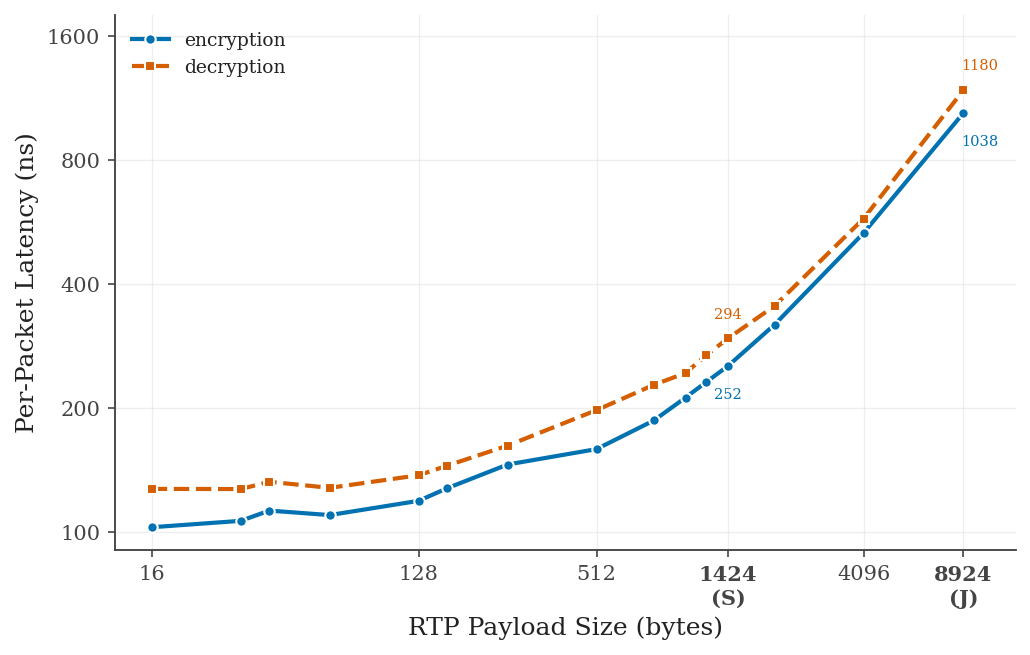

In [164]:
# --- Figure 2: SRTP per-packet latency ---
# Same benchmark data as Figure 1, showing latency instead of throughput.

common_sizes = sorted(set(results.keys()) & set(unprotect_results.keys()))
lat_sizes = np.array(common_sizes)
protect_ns = np.array([results[sz]['mean_ns'] for sz in common_sizes])
unprotect_ns = np.array([unprotect_results[sz]['mean_ns'] for sz in common_sizes])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(lat_sizes, protect_ns, 'o-', color='#0072B2', linewidth=2,
        markersize=5, zorder=5, label='encryption')
ax.plot(lat_sizes, unprotect_ns, 's--', color='#D55E00', linewidth=2,
        markersize=5, zorder=5, label='decryption')

# --- Value labels at the two MTU sizes ---
pt_off = 10
for sz in [1424, 8924]:
    jumbo = sz == 8924;    
    ns_enc = results[sz]['mean_ns']
    ax.annotate(f'{ns_enc:.0f}', (sz, ns_enc),
                textcoords='offset points', xytext=(jumbo * 8, -pt_off - 7),
                fontsize=7, ha='center', va='bottom', color='#0072B2')
    ns_dec = unprotect_results[sz]['mean_ns']
    ax.annotate(f'{ns_dec:.0f}', (sz, ns_dec),
                textcoords='offset points', xytext=(jumbo * 8, pt_off + 5),
                fontsize=7, ha='center', va='top', color='#D55E00')

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Per-Packet Latency (ns)')

xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

ax.set_yscale('log')
ax.set_yticks([100, 200, 400, 800, 1600])
ax.set_yticklabels(['100', '200', '400', '800', '1600'])
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylim(90, 1800)
ax.set_xlim(12, lat_sizes[-1] * 1.5)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_srtp_latency.pdf')
plt.savefig(FIGURES_DIR / 'fig2_srtp_latency.png')
plt.show()

## Table 1: SRTP Performance Summary

Key numbers for the two ST 2110-10 MTU sizes.

Data from Criterion results in `criterion/srtp_throughput/` and
`criterion/srtp_replay_protection/` (replay protection).

In [165]:
# --- Table 1: SRTP performance summary ---

# replay-protection cost, from the replay_protection bench. The rejection
# happens before any decryption (header parse + stream lookup + replay-window
# check) and is size-independent: all measured payload sizes agree within
# ~0.3 ns. We therefore report one number (the median across all sizes).
REPLAY_DIR = CRITERION_DIR / 'srtp_replay_protection' / 'reject_replay'
replay_means = []
for entry in sorted(REPLAY_DIR.iterdir()):
    if not entry.is_dir() or entry.name == 'report':
        continue
    with open(entry / 'new' / 'estimates.json') as f:
        replay_means.append(json.load(f)['mean']['point_estimate'])
replay_med = float(np.median(replay_means))

mtu_sizes = [1424, 8924]

# collecting protect/unprotect data for both MTU sizes
row_data = []
for sz in mtu_sizes:
    row_data.append((results[sz], unprotect_results[sz]))

def fmt_ns(ns):
    """Formats nanoseconds, switching to \u00b5s if >= 1000."""
    if ns >= 1000:
        return f'{ns/1000:.2f} \u00b5s'
    return f'{ns:.1f} ns'

metrics = [
    ('Encrypt latency',    [fmt_ns(row_data[i][0]['mean_ns']) for i in range(2)]),
    ('Decrypt latency',    [fmt_ns(row_data[i][1]['mean_ns']) for i in range(2)]),
    ('Replay check',        [f'~{replay_med:.0f} ns'] * 2),
    ('Encrypt throughput', [f'{row_data[i][0]["throughput_gbps"]:.1f} Gbps' for i in range(2)]),
    ('Decrypt throughput', [f'{row_data[i][1]["throughput_gbps"]:.1f} Gbps' for i in range(2)]),
]

print(f'{"Metric":<24s}  {"Standard MTU":>14s}  {"Jumbo MTU":>14s}')
print('-' * 56)
for name, vals in metrics:
    print(f'{name:<24s}  {vals[0]:>14s}  {vals[1]:>14s}')

Metric                      Standard MTU       Jumbo MTU
--------------------------------------------------------
Encrypt latency                 252.2 ns         1.04 µs
Decrypt latency                 294.3 ns         1.18 µs
Replay check                       ~7 ns           ~7 ns
Encrypt throughput             46.1 Gbps       69.0 Gbps
Decrypt throughput             39.5 Gbps       60.7 Gbps


## Table 2: SRTP Packet Size Overhead

SRTP with AES-128-GCM adds a constant 16-byte authentication tag per packet
(RFC 7714). The 12-byte RTP header is authenticated but not encrypted.
The overhead is most significant for small audio packets and negligible
for large video payloads.

In [166]:
# --- Table 2: Packet size overhead ---


# RTP header is always 12 bytes (RFC 3550, no CSRCs or extensions).
RTP_HDR = 12   # bytes

# SRTP adds a fixed 16-byte GCM authentication tag to every packet.
GCM_TAG = 16   # bytes

# representative payload sizes with their use-case labels
overhead_sizes = [
    (40,   'Wideband speech'),
    (160,  'Fullband mono music'),
    (800,  'Video fragment (small)'),
    (1200, 'Video fragment (near-MTU)'),
    (1424, 'ST 2110 standard MTU'),
    (8924, 'ST 2110 jumbo MTU'),
]

print(f'{"Payload":<8s}  {"Use Case":<26s}  {"RTP":>6s}  {"SRTP":>6s}  {"Overhead":>9s}')
print('-' * 60)
for payload, use_case in overhead_sizes:
    rtp_size = RTP_HDR + payload
    srtp_size = rtp_size + GCM_TAG
    overhead_pct = GCM_TAG / rtp_size * 100
    print(f'{payload:>6d} B  {use_case:<26s}  {rtp_size:>5d} B  {srtp_size:>5d} B  {overhead_pct:>7.1f} %')

Payload   Use Case                       RTP    SRTP   Overhead
------------------------------------------------------------
    40 B  Wideband speech                52 B     68 B     30.8 %
   160 B  Fullband mono music           172 B    188 B      9.3 %
   800 B  Video fragment (small)        812 B    828 B      2.0 %
  1200 B  Video fragment (near-MTU)    1212 B   1228 B      1.3 %
  1424 B  ST 2110 standard MTU         1436 B   1452 B      1.1 %
  8924 B  ST 2110 jumbo MTU            8936 B   8952 B      0.2 %


## Figure 3: FastCast vs. PEP Throughput

Throughput (Gbps) comparison between FastCast (SRTP with AES-128-GCM via libsrtp2) and
PEP (VSF TR-10-13) in two modes:
- **PEP CTR**: AES-128-CTR only (mandatory mode, no authentication)
- **PEP CTR+CMAC-64**: AES-128-CTR + 64-bit truncated AES-CMAC
  (mac-then-encrypt, optional authenticated mode)

Data from Criterion results in `criterion/srtp_throughput/` and
`criterion/pep_throughput/`.

Figure 3 = encryption, Figure 4 = decryption.

In [167]:
# --- Loading PEP benchmark results ---

pep_ctr_enc     = load_criterion_results(PEP_DIR / 'ctr_encrypt')
pep_ctr_dec     = load_criterion_results(PEP_DIR / 'ctr_decrypt')
pep_cmac_enc    = load_criterion_results(PEP_DIR / 'ctr_cmac64_encrypt')
pep_cmac_dec    = load_criterion_results(PEP_DIR / 'ctr_cmac64_decrypt')

print(f'Loaded PEP results: {len(pep_ctr_enc)} payload sizes per mode')
print()
print(f'{"Payload":>8s}  {"CTR enc":>10s}  {"CTR dec":>10s}  {"CMAC enc":>10s}  {"CMAC dec":>10s}')
print('-' * 54)
for sz in sorted(pep_ctr_enc.keys()):
    print(f'{sz:>7d}B  {pep_ctr_enc[sz]["mean_ns"]:>9.1f}  {pep_ctr_dec[sz]["mean_ns"]:>9.1f}'
          f'  {pep_cmac_enc[sz]["mean_ns"]:>9.1f}  {pep_cmac_dec[sz]["mean_ns"]:>9.1f}')

Loaded PEP results: 15 payload sizes per mode

 Payload     CTR enc     CTR dec    CMAC enc    CMAC dec
------------------------------------------------------
     16B       58.6       57.6     1584.8     1609.4
     32B       59.5       58.2     1615.8     1614.4
     40B       47.7       48.4     1618.7     1618.4
     64B       45.9       46.4     1617.1     1620.4
    128B       49.5       50.1     1655.0     1655.5
    160B       53.0       53.9     1663.6     1760.2
    256B       60.4       60.8     1734.0     1740.3
    512B       81.8       79.5     1960.8     1902.3
    800B       97.9       99.0     2122.1     2084.0
   1024B      115.7      116.9     2227.0     2288.7
   1200B      127.0      127.2     2338.4     2354.4
   1424B      148.4      145.2     2549.2     2482.8
   2048B      188.9      189.7     2869.4     2874.8
   4096B      343.3      349.4     4199.7     4271.5
   8924B      695.5      700.0     7310.8     7325.3


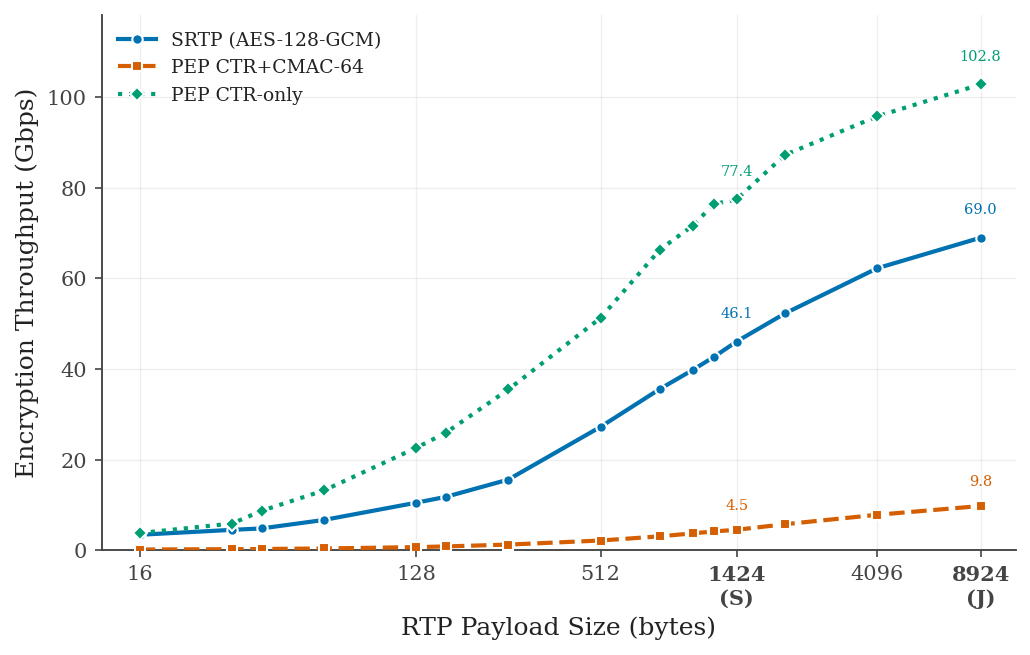

In [168]:
# --- Figure 3: FastCast vs PEP encryption throughput ---

common = sorted(set(results.keys()) & set(pep_ctr_enc.keys()))
sizes = np.array(common)

srtp_enc_tp     = np.array([results[sz]['throughput_gbps'] for sz in common])
pep_ctr_enc_tp  = np.array([pep_ctr_enc[sz]['throughput_gbps'] for sz in common])
pep_cmac_enc_tp = np.array([pep_cmac_enc[sz]['throughput_gbps'] for sz in common])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(sizes, srtp_enc_tp, 'o-', color='#0072B2', linewidth=2,
        markersize=5, zorder=5, label='FastCast (AES-128-GCM)')
ax.plot(sizes, pep_cmac_enc_tp, 's--', color='#D55E00', linewidth=2,
        markersize=5, zorder=5, label='PEP CTR+CMAC-64')
ax.plot(sizes, pep_ctr_enc_tp, 'D:', color='#009E73', linewidth=2,
        markersize=5, zorder=5, label='PEP CTR-only')

# --- Value labels at the two MTU sizes ---
pt_off = 10
for sz in [1424, 8924]:
    tp = results[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#0072B2')
    tp = pep_cmac_enc[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off + 5),
                fontsize=7, ha='center', va='top', color='#D55E00')
    tp = pep_ctr_enc[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#009E73')

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Encryption Throughput (Gbps)')

xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

y_max = max(max(srtp_enc_tp), max(pep_ctr_enc_tp), max(pep_cmac_enc_tp)) * 1.15
ax.set_ylim(0, y_max)
ax.set_xlim(12, sizes[-1] * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_srtp_vs_pep_encrypt.pdf')
plt.savefig(FIGURES_DIR / 'fig3_srtp_vs_pep_encrypt.png')
plt.show()

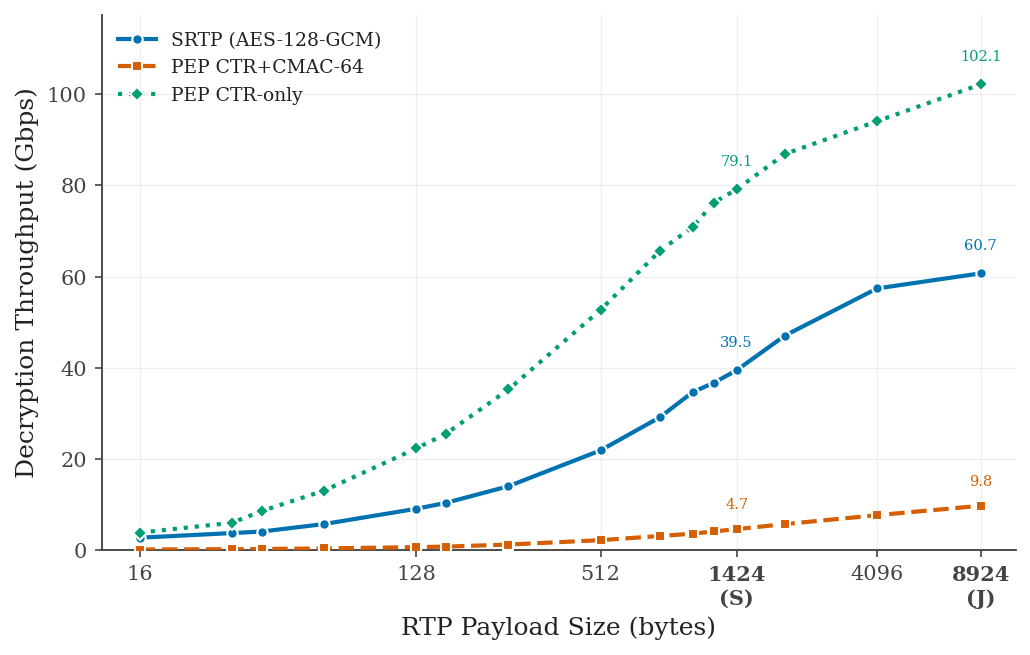

In [169]:
# --- Figure 4: FastCast vs PEP decryption throughput ---

srtp_dec_tp     = np.array([unprotect_results[sz]['throughput_gbps'] for sz in common])
pep_ctr_dec_tp  = np.array([pep_ctr_dec[sz]['throughput_gbps'] for sz in common])
pep_cmac_dec_tp = np.array([pep_cmac_dec[sz]['throughput_gbps'] for sz in common])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(sizes, srtp_dec_tp, 'o-', color='#0072B2', linewidth=2,
        markersize=5, zorder=5, label='FastCast (AES-128-GCM)')
ax.plot(sizes, pep_cmac_dec_tp, 's--', color='#D55E00', linewidth=2,
        markersize=5, zorder=5, label='PEP CTR+CMAC-64')
ax.plot(sizes, pep_ctr_dec_tp, 'D:', color='#009E73', linewidth=2,
        markersize=5, zorder=5, label='PEP CTR-only')

# --- Value labels at the two MTU sizes ---
pt_off = 10
for sz in [1424, 8924]:
    tp = unprotect_results[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#0072B2')
    tp = pep_cmac_dec[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off + 5),
                fontsize=7, ha='center', va='top', color='#D55E00')
    tp = pep_ctr_dec[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#009E73')

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Decryption Throughput (Gbps)')

xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

y_max = max(max(srtp_dec_tp), max(pep_ctr_dec_tp), max(pep_cmac_dec_tp)) * 1.15
ax.set_ylim(0, y_max)
ax.set_xlim(12, sizes[-1] * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_srtp_vs_pep_decrypt.pdf')
plt.savefig(FIGURES_DIR / 'fig4_srtp_vs_pep_decrypt.png')
plt.show()

## Figure 5: MLS Rekey Latency vs. Group Size

Time to perform a group rekey (epoch change) for different MLS group sizes.
A rekey is a self-update commit that advances the group to a new epoch with
fresh key material and triggers SRTP key rotation.

Data from Criterion results in `criterion/rekey/`.

Loaded rekey results for 7 group sizes:
 Members   Sender (µs)   Receiver (µs)
--------------------------------------
       2           271             267
      10           555             441
      50          1056             810
     200          2686            2106
     500          5469            4312
    1000         10242            8177
    5000         56680           47353


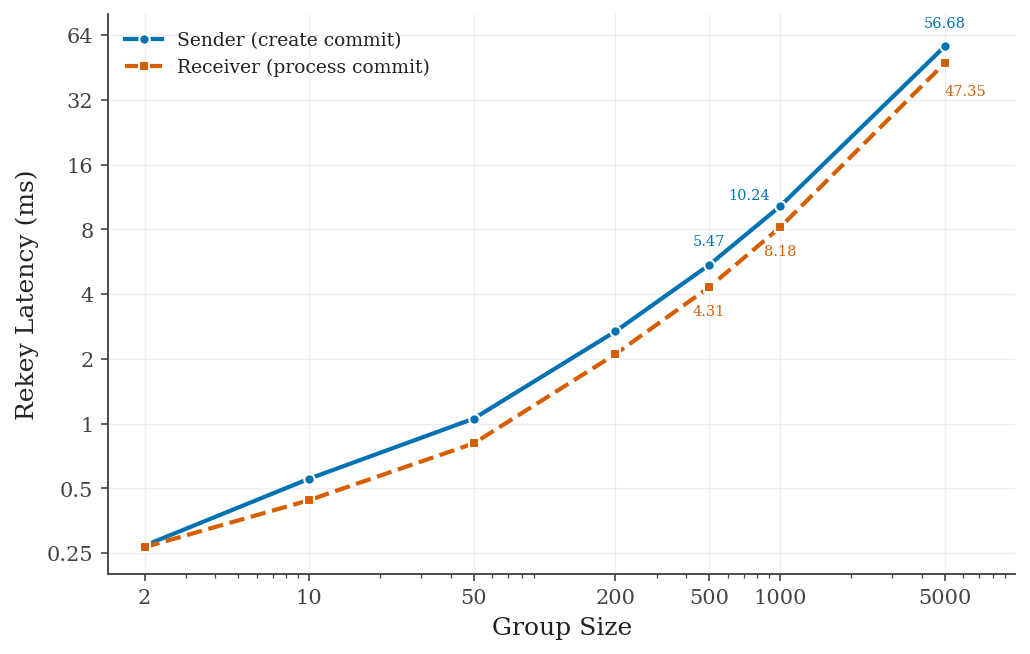

In [170]:
# --- MLS rekey latency data (from Criterion JSON) ---
# "Sender" = creating the rekey commit + exporting SRTP keys
# "Receiver" = processing the incoming commit + exporting SRTP keys.

def load_rekey_results(rekey_dir: Path) -> dict:
    """Loads sender and receiver rekey pipeline latencies from Criterion JSON.
    
    Returns dict with 'group_sizes', 'sender_us', 'receiver_us' arrays.
    """
    group_sizes = []
    sender_us = []
    receiver_us = []
    
    sender_dir = rekey_dir / 'sender_rekey_pipeline'
    receiver_dir = rekey_dir / 'receiver_rekey_pipeline'
    
    # each subdirectory is named by group size (e.g. "2", "10", "50", ...)
    for entry in sorted(sender_dir.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else 0):
        if not entry.is_dir() or not entry.name.isdigit():
            continue
        
        n = int(entry.name)
        
        # sender
        est_path = entry / 'new' / 'estimates.json'
        with open(est_path) as f:
            sender_ns = json.load(f)['mean']['point_estimate']
        
        # receiver
        recv_est = receiver_dir / entry.name / 'new' / 'estimates.json'
        with open(recv_est) as f:
            receiver_ns = json.load(f)['mean']['point_estimate']
        
        group_sizes.append(n)
        sender_us.append(sender_ns / 1000)   # ns -> µs
        receiver_us.append(receiver_ns / 1000)
    
    return {
        'group_sizes': np.array(group_sizes),
        'sender_us': np.array(sender_us),
        'receiver_us': np.array(receiver_us),
    }

rekey = load_rekey_results(REKEY_DIR)
group_sizes = rekey['group_sizes']
sender_rekey_us = rekey['sender_us']
receiver_rekey_us = rekey['receiver_us']

print(f'Loaded rekey results for {len(group_sizes)} group sizes:')
print(f'{"Members":>8s}  {"Sender (µs)":>12s}  {"Receiver (µs)":>14s}')
print('-' * 38)
for i in range(len(group_sizes)):
    print(f'{group_sizes[i]:>8d}  {sender_rekey_us[i]:>12.0f}  {receiver_rekey_us[i]:>14.0f}')

# converting to milliseconds for a cleaner y-axis
sender_rekey_ms = sender_rekey_us / 1000.0
receiver_rekey_ms = receiver_rekey_us / 1000.0

fig, ax = plt.subplots(figsize=(7, 4.5))

# --- Rekey latency curves ---
ax.plot(group_sizes, sender_rekey_ms, 'o-', color='#0072B2', linewidth=2,
        markersize=5, zorder=5, label='Sender (create commit)')
ax.plot(group_sizes, receiver_rekey_ms, 's--', color='#D55E00', linewidth=2,
        markersize=5, zorder=5, label='Receiver (process commit)')

# --- Annotating only the last 3 data points with values ---
pt_off = 8
n_pts = len(group_sizes)

# default offsets: sender above, receiver below
sender_xy   = [(0, pt_off, 'center')] * n_pts
receiver_xy = [(0, -pt_off, 'center')] * n_pts

# some tricks to make sure the value labels don't overlap at the last 2 points
if n_pts >= 5:
    sender_xy[-2]   = (-5, 2, 'right')
    receiver_xy[-1] = (0, -10, 'left')

for i, sz in enumerate(group_sizes):
    # only label the last 3 points
    if i < n_pts - 3:
        continue
    xo, yo, ha = sender_xy[i]
    ax.annotate(f'{sender_rekey_ms[i]:.2f}', (sz, sender_rekey_ms[i]),
                textcoords='offset points', xytext=(xo, yo),
                fontsize=7, ha=ha, va='bottom', color='#0072B2')
    xo, yo, ha = receiver_xy[i]
    ax.annotate(f'{receiver_rekey_ms[i]:.2f}', (sz, receiver_rekey_ms[i]),
                textcoords='offset points', xytext=(xo, yo),
                fontsize=7, ha=ha, va='top', color='#D55E00')

# --- Axis formatting ---
ax.set_xscale('log')
ax.set_xlabel('Group Size')
ax.set_ylabel('Rekey Latency (ms)')

ax.set_xticks(group_sizes)
ax.set_xticklabels([str(s) for s in group_sizes])
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_yscale('log')
ax.set_yticks([0.25, 0.5, 1, 2, 4, 8, 16, 32, 64])
ax.set_yticklabels(['0.25', '0.5', '1', '2', '4', '8', '16', '32', '64'])
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylim(0.2, 80)
ax.set_xlim(group_sizes[0] * 0.7, group_sizes[-1] * 2)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_mls_rekey_latency.pdf')
plt.savefig(FIGURES_DIR / 'fig5_mls_rekey_latency.png')
plt.show()

## Figure 6: Rekey Cost Breakdown

Stacked bar chart showing the cost breakdown of the sender and receiver
rekey pipelines across group sizes. Each bar is decomposed into its
individual sub-operations:

**Sender pipeline:**
1. `propose_self_update` - generates leaf key pair + signs and encrypts Update proposal
2. `commit_builder.build()` - encrypts path secrets to copath nodes
3. `stage_commit()` - encrypts commit
4. `merge_pending_commit` - advances local state to new epoch

**Receiver pipeline:**
1. `unprotect_message` - decrypts commit
2. `process_unverified_message` - verifies signature + decrypts path secrets
3. `merge_staged_commit` - advances local state to new epoch

The SRTP key export (~4 µs) is omitted as it is negligible (<1% of total).
The `stage_commit` cost is derived by subtracting `build` from `build_and_stage`.

Data from Criterion results in `criterion/rekey_breakdown/`.

In [171]:
# --- Figure 6: Rekey cost breakdown (stacked bar chart) ---

def load_breakdown_results(breakdown_dir: Path) -> dict:
    """Loads component-level rekey latencies from Criterion JSON.
    
    Returns dict mapping component_name -> {group_size: mean_us, ...}.
    """
    components = {}
    
    for component_dir in sorted(breakdown_dir.iterdir()):
        if not component_dir.is_dir() or component_dir.name == 'report':
            continue
        
        name = component_dir.name
        components[name] = {}
        
        for size_dir in sorted(component_dir.iterdir(), 
                                key=lambda p: int(p.name) if p.name.isdigit() else 0):
            if not size_dir.is_dir() or not size_dir.name.isdigit():
                continue
            
            est_path = size_dir / 'new' / 'estimates.json'
            if not est_path.exists():
                continue
                
            with open(est_path) as f:
                mean_ns = json.load(f)['mean']['point_estimate']
            
            components[name][int(size_dir.name)] = mean_ns / 1000  # ns -> us
    
    return components

breakdown = load_breakdown_results(REKEY_BREAKDOWN_DIR)

# deriving stage_commit cost by subtraction (build_and_stage - build)
first_key = list(breakdown.keys())[0]
group_sizes_bd = sorted(breakdown[first_key].keys())

stage_commit_us = {}
for sz in group_sizes_bd:
    bas = breakdown['breakdown_sender_build_and_stage'].get(sz, 0)
    bo = breakdown['breakdown_sender_build'].get(sz, 0)
    stage_commit_us[sz] = max(0, bas - bo)

# printing summary table with figure labels
sender_rows = [
    ('Update proposal creation',  'breakdown_sender_propose'),
    ('Tree encryption',      'breakdown_sender_build'),
    ('Commit encryption',    '_stage_commit'),
    ('Epoch advancement',    'breakdown_sender_merge_pending'),
]
receiver_rows = [
    ('Commit decryption',    'breakdown_receiver_unprotect'),
    ('Path decryption',      'breakdown_receiver_verify_stage'),
    ('Epoch advancement',    'breakdown_receiver_merge_staged'),
]

def fmt_us(us):
    if us >= 1000:
        return f'{us/1000:.2f} ms'
    return f'{us:.1f} \u00b5s'

size_hdr = ''.join(f'{"n="+str(s):>12s}' for s in group_sizes_bd)
print(f'{"SENDER":<28s}{size_hdr}')
print('-' * (28 + 12 * len(group_sizes_bd)))
for label, key in sender_rows:
    vals = []
    for sz in group_sizes_bd:
        if key == '_stage_commit':
            vals.append(stage_commit_us.get(sz, 0))
        else:
            vals.append(breakdown[key].get(sz, 0))
    row = ''.join(f'{fmt_us(v):>12s}' for v in vals)
    print(f'{label:<28s}{row}')

print()
print(f'{"RECEIVER":<28s}{size_hdr}')
print('-' * (28 + 12 * len(group_sizes_bd)))
for label, key in receiver_rows:
    vals = [breakdown[key].get(sz, 0) for sz in group_sizes_bd]
    row = ''.join(f'{fmt_us(v):>12s}' for v in vals)
    print(f'{label:<28s}{row}')

SENDER                               n=2        n=10        n=50       n=200       n=500      n=1000      n=5000
----------------------------------------------------------------------------------------------------------------
Update proposal creation         94.9 µs    102.3 µs    112.0 µs    136.3 µs    175.4 µs    240.2 µs    824.4 µs
Tree encryption                 212.6 µs    459.4 µs    857.4 µs     2.09 ms     4.17 ms     7.80 ms    43.27 ms
Commit encryption                23.9 µs     33.7 µs     37.9 µs     56.7 µs     56.9 µs     80.8 µs    338.0 µs
Epoch advancement                19.1 µs     43.3 µs    147.9 µs    480.1 µs     1.13 ms     2.23 ms    12.27 ms

RECEIVER                             n=2        n=10        n=50       n=200       n=500      n=1000      n=5000
----------------------------------------------------------------------------------------------------------------
Commit decryption                18.7 µs     28.6 µs     40.8 µs     66.2 µs    105.7 µs    171

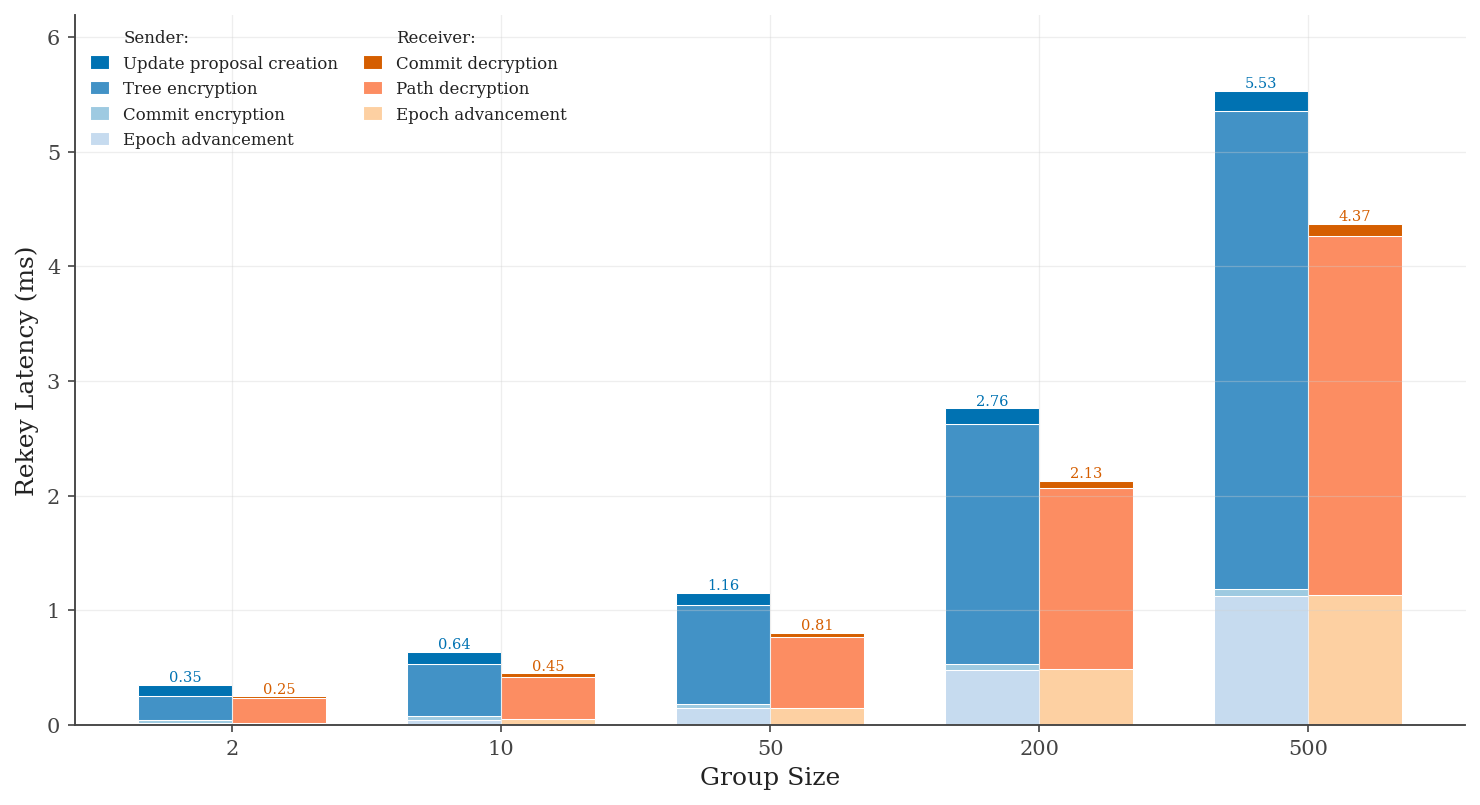

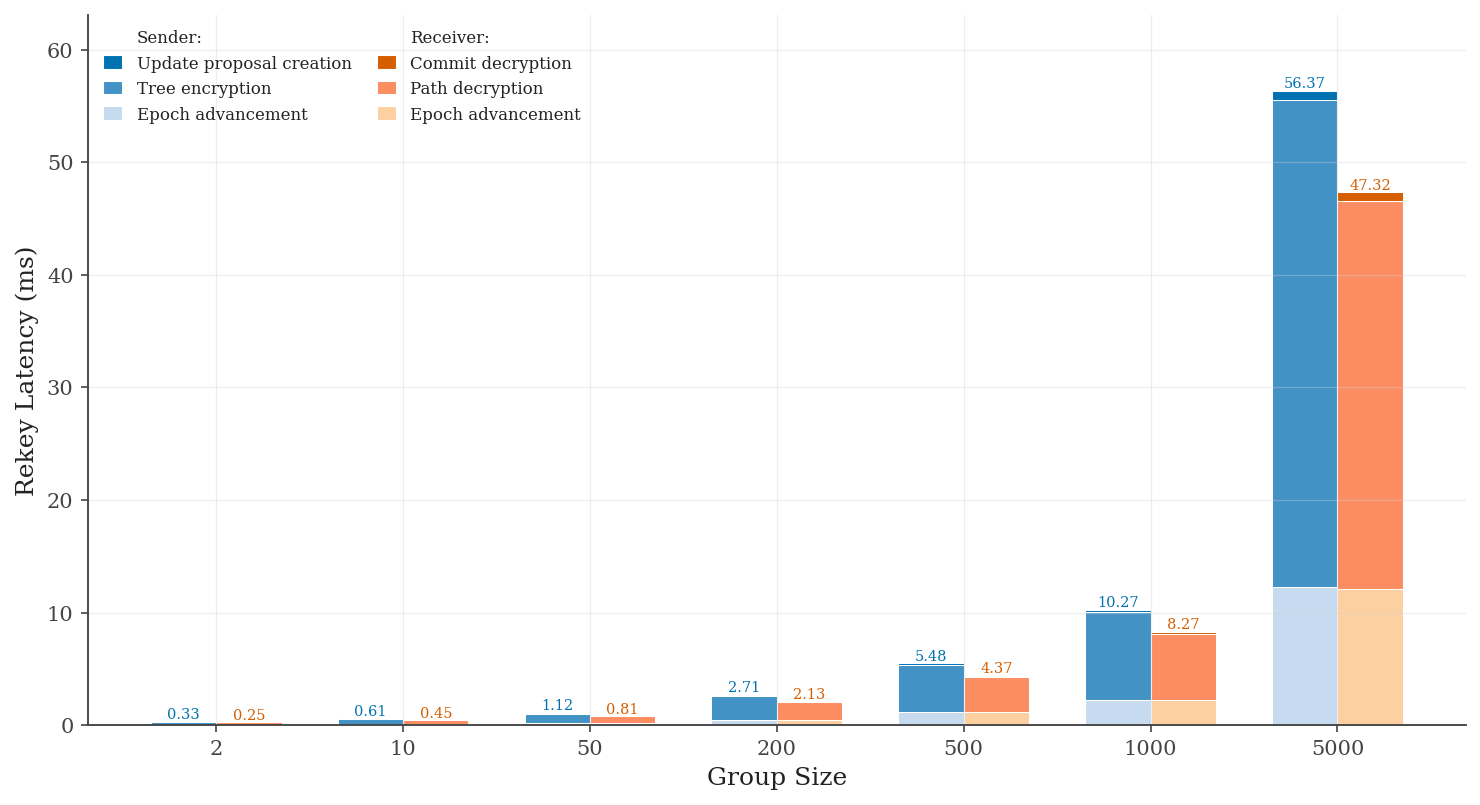

In [172]:
# --- Figure 6: Stacked bar chart (two versions: up to 500, up to 5000) ---

from matplotlib.patches import Patch

# getting group sizes from the first component
first_key = list(breakdown.keys())[0]
group_sizes_bd = sorted(breakdown[first_key].keys())

# deriving stage_commit cost
stage_commit_us = {}
for sz in group_sizes_bd:
    build_and_stage = breakdown['breakdown_sender_build_and_stage'].get(sz, 0)
    build_only = breakdown['breakdown_sender_build'].get(sz, 0)
    stage_commit_us[sz] = max(0, build_and_stage - build_only)

# component names in the order we want them stacked (bottom to top)
sender_components = [
    ('breakdown_sender_propose',        'Update proposal creation'),
    ('breakdown_sender_build',          'Tree encryption'),
    ('_stage_commit',                   'Commit encryption'),
    ('breakdown_sender_merge_pending',  'Epoch advancement'),
]
receiver_components = [
    ('breakdown_receiver_unprotect',     'Commit decryption'),
    ('breakdown_receiver_verify_stage',  'Path decryption'),
    ('breakdown_receiver_merge_staged',  'Epoch advancement'),
]

# colors: 4 shades for sender (blues), 3 shades for receiver (reds)
sender_colors   = ['#0072B2', '#4292c6', '#9ecae1', '#c6dbef']
receiver_colors = ['#D55E00', '#fc8d62', '#fdd0a2']


def plot_breakdown(sizes, suffix, figsize=(10, 5.5), include_commit_enc=True):
    """Plot a stacked bar chart for the given group sizes."""
    n_sizes = len(sizes)
    fig, ax = plt.subplots(figsize=figsize)

    bar_width = 0.35
    x = np.arange(n_sizes)

    # filter sender components if commit encryption is excluded
    if include_commit_enc:
        s_components = sender_components
        s_colors = sender_colors
    else:
        s_components = [(k, l) for k, l in sender_components if k != '_stage_commit']
        s_colors = [sender_colors[i] for i, (k, _) in enumerate(sender_components) if k != '_stage_commit']

    # --- sender bars (left) ---
    sender_bottom = np.zeros(n_sizes)
    for (key, label), color in zip(reversed(s_components), reversed(s_colors)):
        if key == '_stage_commit':
            values = np.array([stage_commit_us.get(sz, 0) for sz in sizes])
        else:
            values = np.array([breakdown[key].get(sz, 0) for sz in sizes])
        values_ms = values / 1000  # us -> ms
        ax.bar(x - bar_width/2, values_ms, bar_width, bottom=sender_bottom,
               color=color, edgecolor='white', linewidth=0.5)
        sender_bottom += values_ms

    # --- receiver bars (right) ---
    receiver_bottom = np.zeros(n_sizes)
    for (key, label), color in zip(reversed(receiver_components), reversed(receiver_colors)):
        values = np.array([breakdown[key].get(sz, 0) for sz in sizes])
        values_ms = values / 1000  # us -> ms
        ax.bar(x + bar_width/2, values_ms, bar_width, bottom=receiver_bottom,
               color=color, edgecolor='white', linewidth=0.5)
        receiver_bottom += values_ms

    # --- total value labels on top of each bar ---
    for i in range(n_sizes):
        ax.text(x[i] - bar_width/2, sender_bottom[i], f'{sender_bottom[i]:.2f}',
                ha='center', va='bottom', fontsize=7, color='#0072B2')
        ax.text(x[i] + bar_width/2, receiver_bottom[i], f'{receiver_bottom[i]:.2f}',
                ha='center', va='bottom', fontsize=7, color='#D55E00')

    # --- custom legend with "Sender:" / "Receiver:" group headers ---
    legend_handles = []
    legend_handles.append(Patch(facecolor='none', edgecolor='none', label='Sender:'))
    for (_, label), color in zip(s_components, s_colors):
        legend_handles.append(Patch(facecolor=color, edgecolor='white', label=label))
    legend_handles.append(Patch(facecolor='none', edgecolor='none', label='Receiver:'))
    for (_, label), color in zip(receiver_components, receiver_colors):
        legend_handles.append(Patch(facecolor=color, edgecolor='white', label=label))

    ax.legend(handles=legend_handles, loc='upper left', ncol=2, fontsize=8,
              handlelength=1.2, handleheight=1.0, columnspacing=1.5)

    # --- axis formatting ---
    ax.set_xlabel('Group Size')
    ax.set_ylabel('Rekey Latency (ms)')
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.set_ylim(0, max(max(sender_bottom), max(receiver_bottom)) * 1.12)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'fig6_rekey_breakdown{suffix}.pdf')
    plt.savefig(FIGURES_DIR / f'fig6_rekey_breakdown{suffix}.png')
    plt.show()


# Figure 6a: group sizes up to 500 (with commit encryption)
sizes_500 = [s for s in group_sizes_bd if s <= 500]
plot_breakdown(sizes_500, suffix='')

# Figure 6b: all group sizes up to 5000 (without commit encryption)
plot_breakdown(group_sizes_bd, suffix='_full', include_commit_enc=False)

## Table 3: Key Derivation Pipeline

The two-stage pipeline that turns an MLS epoch secret into SRTP session
keys: MLS key export (HKDF) followed by the SRTP KDF (AES-128-CTR).
Both stages run once at session setup and again on each epoch change, not
per packet.

Data from Criterion results in `criterion/key_derivation/`.

In [173]:
# --- Table 3: Key derivation pipeline (from Criterion JSON) ---

def read_criterion_mean_us(bench_dir: Path) -> float:
    """Reads the mean latency (µs) from a Criterion benchmark directory."""
    est_path = bench_dir / 'new' / 'estimates.json'
    with open(est_path) as f:
        return json.load(f)['mean']['point_estimate'] / 1000  # ns -> µs

mls_export_us = read_criterion_mean_us(KEY_DERIVATION_DIR / 'mls_key_export')
srtp_kdf_us   = read_criterion_mean_us(KEY_DERIVATION_DIR / 'srtp_kdf')
full_kd_us    = read_criterion_mean_us(KEY_DERIVATION_DIR / 'full_key_derivation')

mls_share  = round(mls_export_us / full_kd_us * 100)
srtp_share = 100 - mls_share

kd_stages = [
    ('MLS key export (2x HKDF)',    f'{mls_export_us:.2f} µs', f'{mls_share}%'),
    ('SRTP KDF (4x AES-128-CTR)',   f'{srtp_kdf_us:.2f} µs',  f'{srtp_share}%'),
    ('Total pipeline',               f'{full_kd_us:.2f} µs',   '100%'),
]

print(f'{"Stage":<34s}  {"Latency":>10s}  {"Share":>6s}')
print('-' * 54)
for stage, lat, share in kd_stages:
    print(f'{stage:<34s}  {lat:>10s}  {share:>6s}')

# comparing against smallest rekey cost
smallest_sender_us = sender_rekey_us[0]
kd_pct = full_kd_us / smallest_sender_us * 100
print()
print(f'For comparison: MLS rekey commit ({group_sizes[0]} members) = {smallest_sender_us:.0f} µs')
print(f'Key derivation is <{max(2, round(kd_pct))}% of the total rekey cost.')

Stage                                  Latency   Share
------------------------------------------------------
MLS key export (2x HKDF)               4.21 µs     82%
SRTP KDF (4x AES-128-CTR)              0.87 µs     18%
Total pipeline                         5.12 µs    100%

For comparison: MLS rekey commit (2 members) = 271 µs
Key derivation is <2% of the total rekey cost.


## Figure 7: Per-Member Memory Usage of MLS Group State

Each member of an MLS group holds a local copy of the group state in memory.
This includes four components:

1. **MlsGroup struct** -- the ratchet tree (a binary tree of public encryption
   keys, one leaf per member), the group context, and symmetric key material
   for encrypting/decrypting MLS handshake messages (commits, proposals).
2. **Signature key pair** -- the member's private signing key, used to
   authenticate commits and proposals (constant size, independent of group size).
3. **HPKE encryption key pairs** -- private decryption keys for the nodes on
   the member's path from its leaf to the root of the ratchet tree. These are
   needed to decrypt path secrets when another member performs a rekey. The
   number of keys equals the tree depth (log₂ of the group size).
4. **Exported SRTP key material** -- the master key (16 bytes) and master salt
   (12 bytes) derived from the MLS epoch secret via the MLS exporter and used
   to encrypt/decrypt the actual media (RTP) packets. Constant 28 bytes.

The ratchet tree dominates: it grows linearly with the number of members,
while the other three components are either constant or logarithmic.

Data from `benches/results/memory_usage/memory_usage.json`, generated by
`cargo bench --package safecast-core --bench memory_usage`.

  Group Size       Bytes          KB
------------------------------------
           2        3812         3.7
          10       14825        14.5
          50       51418        50.2
         200      191893       187.4
         500      404481       395.0
        1000      803557       784.7
        5000     5621165      5489.4

Per-member cost (largest group): 1124 bytes


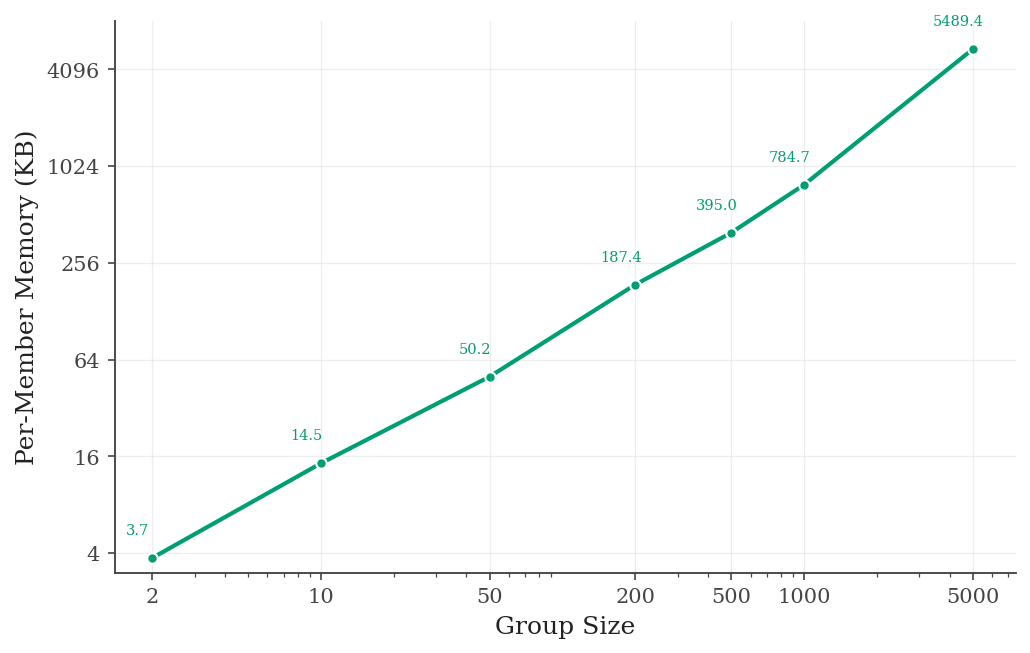

In [174]:
# --- Figure 7: Per-member memory usage of MLS group state ---

MEMORY_USAGE_PATH = Path('benches/results/memory_usage/memory_usage.json')

with open(MEMORY_USAGE_PATH) as f:
    mem_data = json.load(f)

# extracting group sizes and memory usage
mem_sizes = np.array([d['group_size'] for d in mem_data])
mem_bytes = np.array([d['bytes'] for d in mem_data])

# converting to KB
mem_kb = mem_bytes / 1024.0

# printing table
print(f'{"Group Size":>12s}  {"Bytes":>10s}  {"KB":>10s}')
print('-' * 36)
for i in range(len(mem_sizes)):
    print(f'{mem_sizes[i]:>12d}  {mem_bytes[i]:>10d}  {mem_kb[i]:>10.1f}')

# per-member cost
print(f'\nPer-member cost (largest group): {mem_bytes[-1] / mem_sizes[-1]:.0f} bytes')

# plotting 
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(mem_sizes, mem_kb, 'o-', color='#009E73', linewidth=2, markersize=5, zorder=5)

# value labels on each point
for i in range(len(mem_sizes)):
    ax.annotate(f'{mem_kb[i]:.1f}', (mem_sizes[i], mem_kb[i]),
                textcoords='offset points', xytext=(-7, 10),
                fontsize=7, ha='center', va='bottom', color='#009E73')

ax.set_xscale('log')
ax.set_xlabel('Group Size')
ax.set_ylabel('Per-Member Memory (KB)')

ax.set_xticks(mem_sizes)
ax.set_xticklabels([str(s) for s in mem_sizes])
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_yscale('log')
ax.set_yticks([4, 16, 64, 256, 1024, 4096])
ax.set_yticklabels(['4', '16', '64', '256', '1024', '4096'])
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_ylim(3, max(mem_kb) * 1.5)
ax.set_xlim(mem_sizes[0] * 0.7, mem_sizes[-1] * 1.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_memory_usage.pdf')
plt.savefig(FIGURES_DIR / 'fig7_memory_usage.png')
plt.show()

## Figure 8: SRTCP Interleaving Overhead

Compares SRTP `protect()` throughput with and without periodic
SRTCP `protect_rtcp()` interleaving, for the two ST 2110-10 MTU sizes
(standard 1424 B and jumbo 8924 B).

For each payload size, two benchmarks are run:
1. **Baseline:** `protect()` loop (no RTCP)
2. **Interleaved:** same loop, but every N-th packet triggers a
   `protect_rtcp()` call on a 100-byte RTCP packet, with N sized so
   that one RTCP packet falls in each 5-second interval of media
   (RFC 3550 §6.2) at the ST 2110 packet rate

The RTCP packet size is 100 bytes, based on real-world examples:
- [ShareTechnote](https://www.sharetechnote.com/html/IMS_SIP_RTP_RTCP.html): 72-byte RTCP packet
- [Wireshark](https://wiki.wireshark.org/RTCP): 100-byte RTCP packet

Data from Criterion results in `criterion/srtp_rtcp_interleaving/`.

Scenario                        Baseline   Interleaved      Diff
--------------------------------------------------------------
Standard MTU (1424 B)             46.00        45.89    -0.23%
Jumbo MTU (8924 B)                69.03        68.92    -0.15%


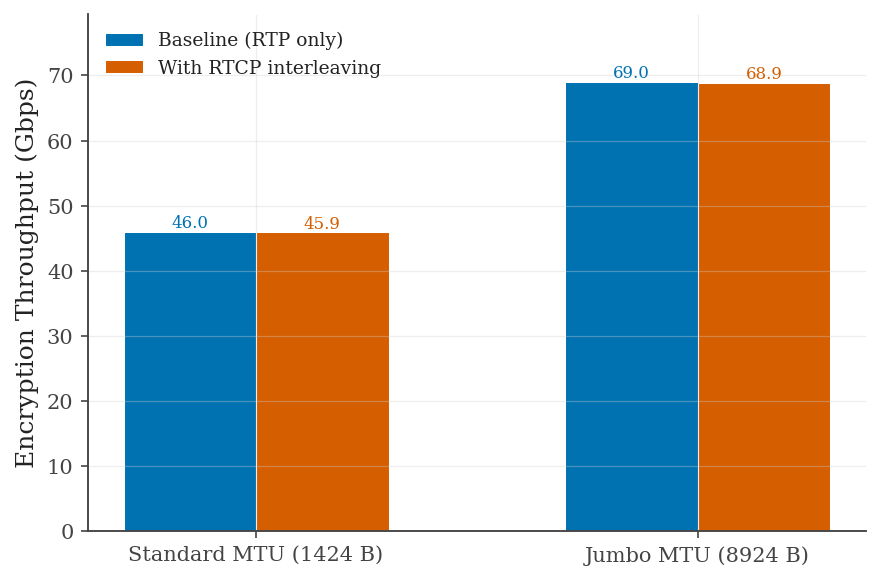

In [175]:
# --- Figure 8: SRTCP interleaving overhead ---

RTCP_DIR = CRITERION_DIR / 'srtp_rtcp_interleaving'

# Loading baseline and interleaved results for each MTU size.
# Directory structure: srtp_rtcp_interleaving/{baseline,interleaved}/<label>/new/estimates.json
scenarios = [
    (1424, '1424B_standard', 'Standard MTU (1424 B)'),
    (8924, '8924B_jumbo',    'Jumbo MTU (8924 B)'),
]

# Each SRTP packet, besides the payload, consists of:
# - RTP header: 12 bytes
# - GCM tag: 16 bytes
RTP_HDR = 12
GCM_TAG = 16

# collecting baseline throughput, interleaved throughput, and labels 
baseline_tp = []
interleaved_tp = []
labels = []

# calculating baseline and interleaved throughput for each MTU
for payload_size, label, display_name in scenarios:
    packet_bytes = RTP_HDR + payload_size + GCM_TAG

    # baseline
    est_path = RTCP_DIR / 'baseline' / label / 'new' / 'estimates.json'
    with open(est_path) as f:
        mean_ns = json.load(f)['mean']['point_estimate']
    baseline_tp.append((packet_bytes * 8) / mean_ns)  # Gbps

    # interleaved
    est_path = RTCP_DIR / 'interleaved' / label / 'new' / 'estimates.json'
    with open(est_path) as f:
        mean_ns = json.load(f)['mean']['point_estimate']
    interleaved_tp.append((packet_bytes * 8) / mean_ns)  # Gbps

    labels.append(display_name)

# printing summary
print(f'{"Scenario":<28s}  {"Baseline":>10s}  {"Interleaved":>12s}  {"Diff":>8s}')
print('-' * 62)
for i in range(len(scenarios)):
    diff_pct = (interleaved_tp[i] - baseline_tp[i]) / baseline_tp[i] * 100
    print(f'{labels[i]:<28s}  {baseline_tp[i]:>9.2f}  {interleaved_tp[i]:>11.2f}  {diff_pct:>+7.2f}%')

# --- Grouped bar chart ---

x = np.arange(len(labels))
bar_width = 0.3

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - bar_width/2, baseline_tp, bar_width,
               color='#0072B2', edgecolor='white', linewidth=0.5,
               label='Baseline (RTP only)')
bars2 = ax.bar(x + bar_width/2, interleaved_tp, bar_width,
               color='#D55E00', edgecolor='white', linewidth=0.5,
               label='With RTCP interleaving')

# value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=8, color='#0072B2')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=8, color='#D55E00')

ax.set_ylabel('Encryption Throughput (Gbps)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(max(baseline_tp), max(interleaved_tp)) * 1.15)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_rtcp_interleaving.pdf')
plt.savefig(FIGURES_DIR / 'fig8_rtcp_interleaving.png')
plt.show()

## Figure 9: Granularity Throughput vs. Video Bitrates

Data-plane `protect`/`unprotect` throughput for the three keying granularities
(epoch-only / frame-level / packet-level) across different payload sizes. Epoch-only means one key per MLS epoch (no within-epoch rekeying), so it is the original baseline, with
uncompressed ST 2110 video bitrates as reference lines. Frame-level coincides
with epoch-only (its once-per-frame rekey amortizes away over thousands of
packets). Packet-level shows where per-packet rekeying crosses each format's
required bitrate.

Data from Criterion results in `criterion/granularity_protect/` and
`criterion/granularity_unprotect/`.

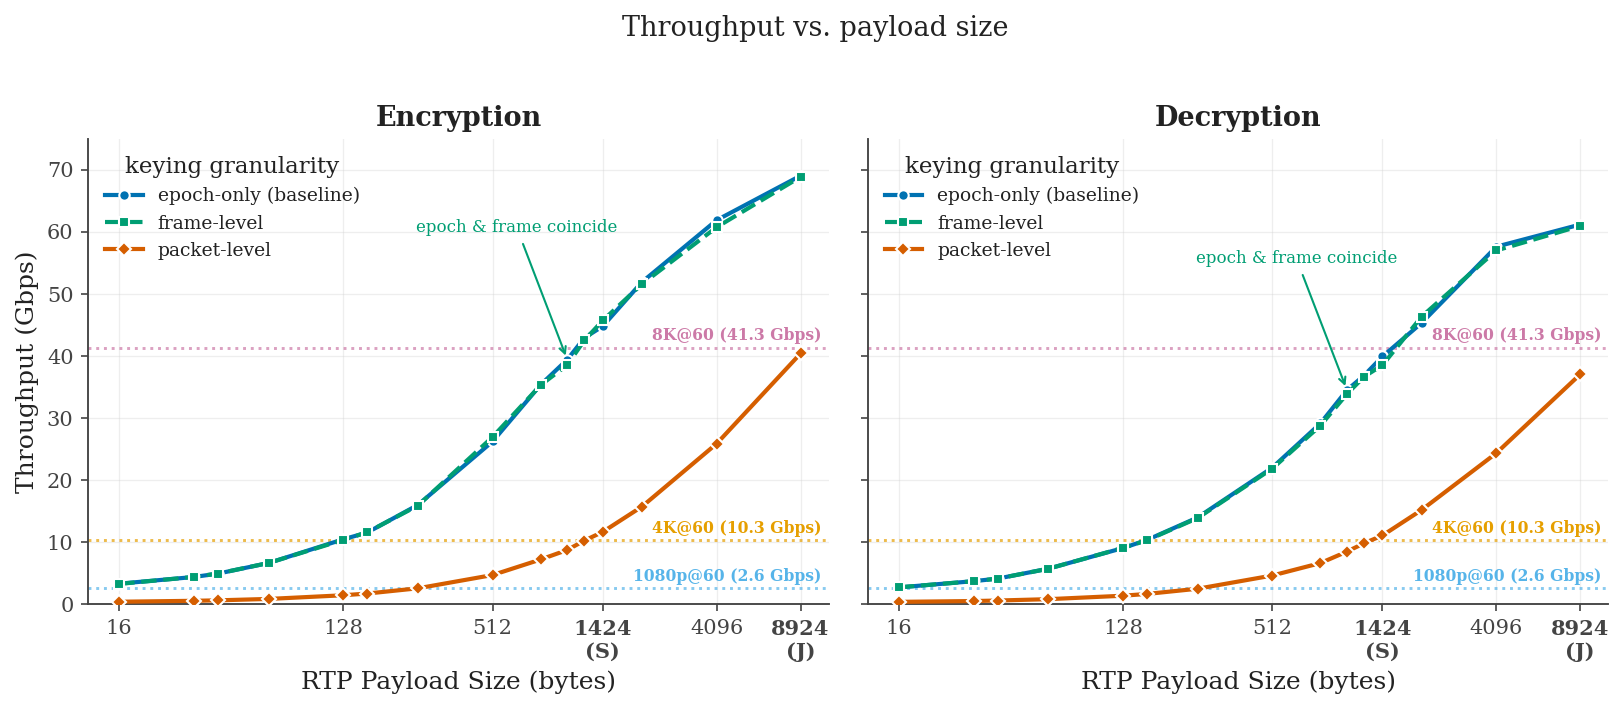

In [176]:
# --- Figure 9: granularity throughput + uncompressed-video format lines ---

# loading the three series (epoch/frame/packet) for both directions from the
# criterion results; keys are payload sizes, values mean_ns + Gbps
GRAN = ['epoch', 'frame', 'packet']
gran_protect = {g: load_criterion_results(CRITERION_DIR / 'granularity_protect' / g) for g in GRAN}
gran_unprotect = {g: load_criterion_results(CRITERION_DIR / 'granularity_unprotect' / g) for g in GRAN}

# per-granularity line styles
GRAN_STYLE = {
    'epoch':  dict(color='#0072B2', marker='o', ls='-',  label='epoch-only (baseline)'),
    'frame':  dict(color='#009E73', marker='s', ls='--', label='frame-level'),
    'packet': dict(color='#D55E00', marker='D', ls='-',  label='packet-level'),
}

# uncompressed ST 2110 reference bitrates:
# these are the rates the formats require; the measured lines are capacity,
# so a format is feasible where the capacity line sits above its reference line
GRAN_VIDEO = [('1080p@60', 2.58, '#56B4E9'), ('4K@60', 10.32, '#E69F00'), ('8K@60', 41.29, '#CC79A7')]
# (S) = ST 2110-10 standard MTU, (J) = jumbo
GRAN_XT = [16, 128, 512, 1424, 4096, 8924]
GRAN_XL = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']

# x-axis styling: log2 scale, fixed ticks, bold MTU labels
def _gran_style_x(ax):
    ax.set_xscale('log', base=2)
    ax.set_xticks(GRAN_XT); ax.set_xticklabels(GRAN_XL)
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    for lbl in ax.xaxis.get_ticklabels():
        if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
            lbl.set_fontweight('bold')

# two panels sharing the y axis: encryption left, decryption right
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, data, title in [(axes[0], gran_protect, 'Encryption'),
                        (axes[1], gran_unprotect, 'Decryption')]:
    # --- the three measured frequency legend ---
    for g in GRAN:
        xs = np.array(list(data[g].keys()))
        ys = np.array([data[g][s]['throughput_gbps'] for s in xs])
        ax.plot(xs, ys, **GRAN_STYLE[g], linewidth=2, markersize=5, zorder=5)
    # --- horizontal required-bitrate reference lines per video format ---
    for name, br, col in GRAN_VIDEO:
        ax.axhline(br, color=col, ls=':', lw=1.4, alpha=0.7)
        ax.text(0.99, br + 0.6, f'{name} ({br:.1f} Gbps)', transform=ax.get_yaxis_transform(),
                ha='right', va='bottom', fontsize=7.5, color=col, fontweight='bold')
    _gran_style_x(ax)
    # label of x-axis
    ax.set_xlabel('RTP Payload Size (bytes)'); ax.set_title(title)
    ax.set_xlim(12, 8924 * 1.3); ax.set_ylim(0, 75)

# text saying that the epoch and frame lines sit on top of each other
axes[0].annotate('epoch & frame coincide', xy=(1024, gran_protect['epoch'][1024]['throughput_gbps']),
                 xytext=(640, 60), fontsize=8, ha='center', color='#009E73',
                 arrowprops=dict(arrowstyle='->', color='#009E73', lw=1))
axes[1].annotate('epoch & frame coincide', xy=(1024, gran_unprotect['epoch'][1024]['throughput_gbps']),
                 xytext=(640, 55), fontsize=8, ha='center', color='#009E73',
                 arrowprops=dict(arrowstyle='->', color='#009E73', lw=1))
# label of y-axis
axes[0].set_ylabel('Throughput (Gbps)')
axes[0].legend(loc='upper left', title='keying granularity')
axes[1].legend(loc='upper left', title='keying granularity')

## title
fig.suptitle('Throughput vs. payload size', y=1.02, fontsize=13)
plt.tight_layout()
# saving to both PDF and PNG
plt.savefig(FIGURES_DIR / 'fig9_granularity_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig9_granularity_throughput.png')
plt.show()

## Figure 10: Cost of Per-Packet Rekeying

Left: per-packet encrypt latency. Frame-level sits on epoch-only, while
packet-level runs above by a near-constant ~720 ns. This is the rekey tax
(ratchet's two HKDF-Expands + the AES key install), independent of payload size.

Right: the packet-level/epoch-only ratio. As the tax is fixed while the
crypto scales with size, the relative rekey cost falls from ~7.8x at 16 B to ~1.7x at
the jumbo MTU. Hence, per-packet rekeying hurts small packets most.

Data from Criterion results in `criterion/granularity_protect/` and
`criterion/granularity_unprotect/`.

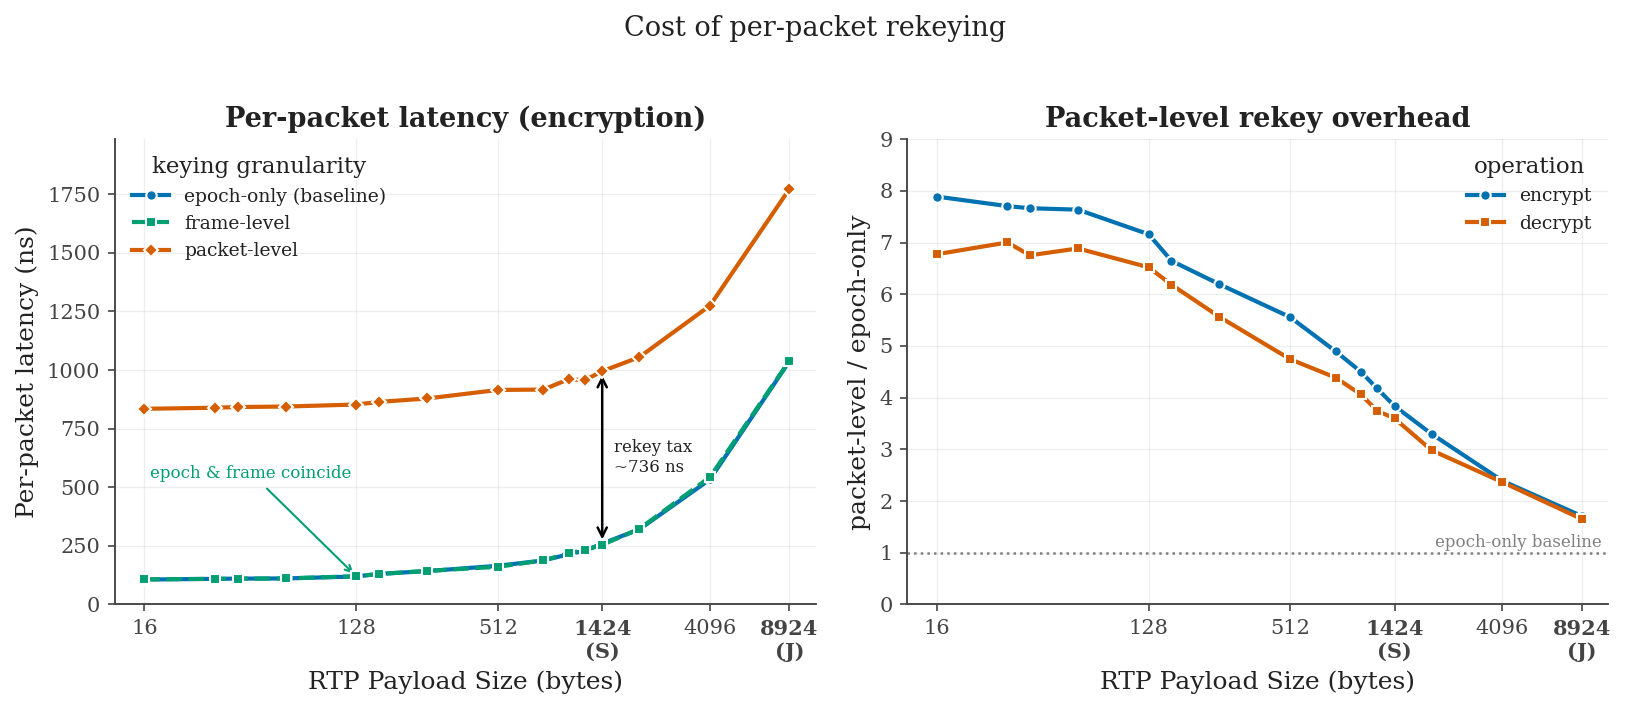

In [177]:
# --- Figure 10: cost of per-packet rekeying (flat tax + overhead ratio) ---

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.6))

# (left) per-packet encrypt latency
for g in GRAN:
    xs = np.array(list(gran_protect[g].keys()))
    ys = np.array([gran_protect[g][s]['mean_ns'] for s in xs])
    axL.plot(xs, ys, **GRAN_STYLE[g], linewidth=2, markersize=5, zorder=5)
# --- "rekey tax" arrow at the standard MTU ---
# the vertical gap packet minus epoch is the per-packet rekey cost. It is
# roughly the same at every payload size (the tax is size-independent).
x0 = 1424
e0, p0 = gran_protect['epoch'][x0]['mean_ns'], gran_protect['packet'][x0]['mean_ns']
axL.annotate('', xy=(x0, p0), xytext=(x0, e0), arrowprops=dict(arrowstyle='<->', color='black', lw=1.2))
axL.text(x0 * 1.12, (e0 + p0) / 2, f'rekey tax\n~{p0 - e0:.0f} ns', fontsize=8, va='center')
axL.annotate('epoch & frame coincide', xy=(128, gran_protect['epoch'][128]['mean_ns']),
             xytext=(17, 560), fontsize=8, ha='left', va='center', color='#009E73',
             arrowprops=dict(arrowstyle='->', color='#009E73', lw=1))
_gran_style_x(axL)
# label of x-axis and y-axis
axL.set_xlabel('RTP Payload Size (bytes)'); axL.set_ylabel('Per-packet latency (ns)')
# title
axL.set_title('Per-packet latency (encryption)')
# legend
axL.set_xlim(12, 8924 * 1.3); axL.set_ylim(0, gran_protect['packet'][8924]['mean_ns'] * 1.12)
axL.legend(loc='upper left', title='keying granularity')

# (right) packet-level/epoch-only overhead ratio, encrypt + decrypt:
# how many times slower per-packet rekeying is than the baseline. The ratio
# shrinks with payload size because the flat tax is divided by a growing
# per-packet crypto cost
for data, lab, col, mk in [(gran_protect, 'encrypt', '#0072B2', 'o'),
                           (gran_unprotect, 'decrypt', '#D55E00', 's')]:
    xs = np.array(list(data['epoch'].keys()))
    ratio = np.array([data['packet'][s]['mean_ns'] / data['epoch'][s]['mean_ns'] for s in xs])
    axR.plot(xs, ratio, marker=mk, ls='-', color=col, lw=2, markersize=5, label=lab, zorder=5)
# ratio 1.0 = no overhead: where epoch-only (and effectively frame) sit
axR.axhline(1.0, color='gray', ls=':', lw=1.2)
axR.text(0.99, 1.04, 'epoch-only baseline', transform=axR.get_yaxis_transform(),
         ha='right', va='bottom', fontsize=8, color='gray')
_gran_style_x(axR)
# label of x-axis and y-axis
axR.set_xlabel('RTP Payload Size (bytes)'); axR.set_ylabel('packet-level / epoch-only')
# title
axR.set_title('Packet-level rekey overhead')
# legend
axR.set_xlim(12, 8924 * 1.3); axR.set_ylim(0, 9)
axR.legend(loc='upper right', title='operation')

# title
fig.suptitle('Cost of per-packet rekeying', y=1.02, fontsize=13)
plt.tight_layout()
# saving to both PDF and PNG
plt.savefig(FIGURES_DIR / 'fig10_granularity_cost.pdf')
plt.savefig(FIGURES_DIR / 'fig10_granularity_cost.png')
plt.show()

## Figures 11-13: Realistic Delivery

The `realistic_receiver` bench replays the stream through a simulated ST 2022-7
dual-path network and times each decryption. Its `--sweep` mode writes one CSV
row per run to `benches/results/realistic_receiver/raw.csv`. The runs are the payload sweep
(15 sizes x 3 granularities x {undisturbed, disturbed}) plus the packet-level and
frame-level K sweeps and the every-n sweep. The cell below reads that CSV.

You can regenerate the CSV with:
```bash
cargo bench --package safecast-core --bench realistic_receiver -- --sweep
```

In [178]:
# --- loading the realistic-receiver results from raw.csv ---
import csv

# the path to the CSV file
RAW_CSV = Path('benches/results/realistic_receiver/raw.csv')

# One line of the CSV = one run of the sweep, holding that run's ~56
# values (its settings and its results). Each line becomes a small
# lookup table keyed by column name: for a run r, r['payload'] is its
# payload size, r['mean_ns'] its mean decrypt time, and so on. The CSV
# stores everything as text, so number columns are converted to floats,
# and empty cells (a statistic with no data in that run) become None.
raw_rows = []
with open(RAW_CSV) as f:
    for r in csv.DictReader(f):
        for k, v in r.items():
            if k not in ('group', 'granularity', 'single_path'):
                r[k] = float(v) if v != '' else None
        # the CSV stores booleans as true/false text
        r['single_path'] = r['single_path'] == 'true'
        raw_rows.append(r)

# The payload sweep, arranged for plotting: realistic[(granularity,
# condition)][payload] gives that one run's lookup table from above.
# For example realistic[('packet', 'disturbed')][1424] holds every value
# of the disturbed packet-level run at 1424 B.
# clean rows are the single-path ones, disturbed rows are the dual-path ones
realistic = {}
for g in GRAN:
    for cond, single in (('clean', True), ('disturbed', False)):
        sel = [r for r in raw_rows if r['group'] == 'payload'
               and r['granularity'] == g and r['single_path'] == single]
        realistic[(g, cond)] = {int(r['payload']): r for r in sel}

# the two K sweeps as {K: keying-loss rate}, for example
# k_packet[16] == 0.0728 (7.28% loss at K=16) and k_packet[456] == 0.0
k_packet = {int(r['key_window']): r['keying_loss'] for r in raw_rows if r['group'] == 'k_packet'}
k_frame = {int(r['key_window']): r['keying_loss'] for r in raw_rows if r['group'] == 'k_frame'}

print(f'{len(raw_rows)} sweep rows loaded '
      f'({sum(len(v) for v in realistic.values())} payload runs, '
      f'{len(k_packet)} packet-K runs, {len(k_frame)} frame-K runs)')

128 sweep rows loaded (90 payload runs, 15 packet-K runs, 11 frame-K runs)


## Figure 11: Realistic Decryption Throughput vs. Payload Size

Solid = the disturbed dual-path network (100 us jitter per path, 1e-4 per-path loss, 2 ms
path skew). 

Dashed = a single undisturbed path through the same receiver.
Each granularity's dashed line runs on (or within a few percent of) its solid
line: disturbance reorders the decryption work but adds none, so throughput
survives the network. Epoch and frame coincide as in figure 9.

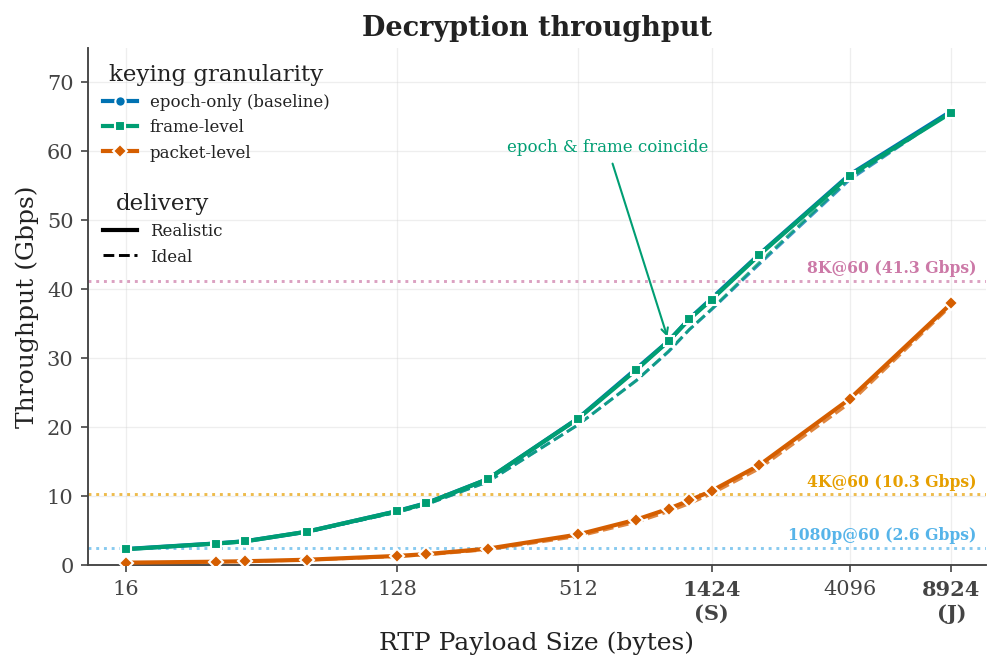

In [179]:
# --- Figure 11: realistic decryption throughput, disturbed vs clean ---
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6.8, 4.6))

# one color per granularity (as in fig9), solid = realistic (disturbed), dashed = ideal (undisturbed)
for g in GRAN:
    st = GRAN_STYLE[g]
    xs = np.array(sorted(realistic[(g, 'disturbed')].keys()))
    y_dist = np.array([realistic[(g, 'disturbed')][s]['gbps'] for s in xs])
    y_clean = np.array([realistic[(g, 'clean')][s]['gbps'] for s in xs])
    ax.plot(xs, y_dist, color=st['color'], marker=st['marker'], ls='-',
            lw=2, markersize=5, zorder=5)
    ax.plot(xs, y_clean, color=st['color'], ls='--', lw=1.4, alpha=0.75, zorder=4)

# the same required-bitrate reference lines as fig9
for name, br, col in GRAN_VIDEO:
    ax.axhline(br, color=col, ls=':', lw=1.4, alpha=0.7)
    ax.text(0.99, br + 0.6, f'{name} ({br:.1f} Gbps)', transform=ax.get_yaxis_transform(),
            ha='right', va='bottom', fontsize=7.5, color=col, fontweight='bold')

# "epoch & frame coincide" label
# the epoch line is invisible without this, as frame sits exactly on top of it
ax.annotate('epoch & frame coincide',
            xy=(1024, realistic[('epoch', 'disturbed')][1024]['gbps']),
            xytext=(640, 60), fontsize=8, ha='center', color='#009E73',
            arrowprops=dict(arrowstyle='->', color='#009E73', lw=1))

_gran_style_x(ax)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Throughput (Gbps)')
ax.set_xlim(12, 8924 * 1.3)
ax.set_ylim(0, 75)

# two legends: color says the granularity, line style says the condition
gran_handles = [Line2D([], [], color=GRAN_STYLE[g]['color'], marker=GRAN_STYLE[g]['marker'],
                       ls='-', lw=2, markersize=5, label=GRAN_STYLE[g]['label']) for g in GRAN]
cond_handles = [Line2D([], [], color='black', ls='-', lw=2, label='Realistic'),
                Line2D([], [], color='black', ls='--', lw=1.4, label='Ideal')]
leg_gran = ax.legend(handles=gran_handles, loc='upper left', title='keying granularity', fontsize=8)
ax.add_artist(leg_gran)
ax.legend(handles=cond_handles, loc='upper left', bbox_to_anchor=(0.0, 0.75),
          title='delivery', fontsize=8)

ax.set_title('Decryption throughput')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_realistic_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig11_realistic_throughput.png')
plt.show()

## Figure 12: Realistic Per-Packet Latency and its Slowest Calls

Two lines per granularity: solid = the mean decryption latency, dotted = the
p99.9 of the same run (the time the slowest 0.1% of decryptions exceed). 
Under undisturbed delivery (left) every
dotted line hugs its solid line: without reordering there are no expensive
calls. Under disturbance (right) the means stay at similar places but the dotted lines
separate by keying fineness. Packet-level's p99.9 climbs to tens of
microseconds at small payloads: late packets force catch-up decryptions that
derive many keys at once, and the smaller the payload, the more positions the
same jitter spans, the deeper those catch-ups.

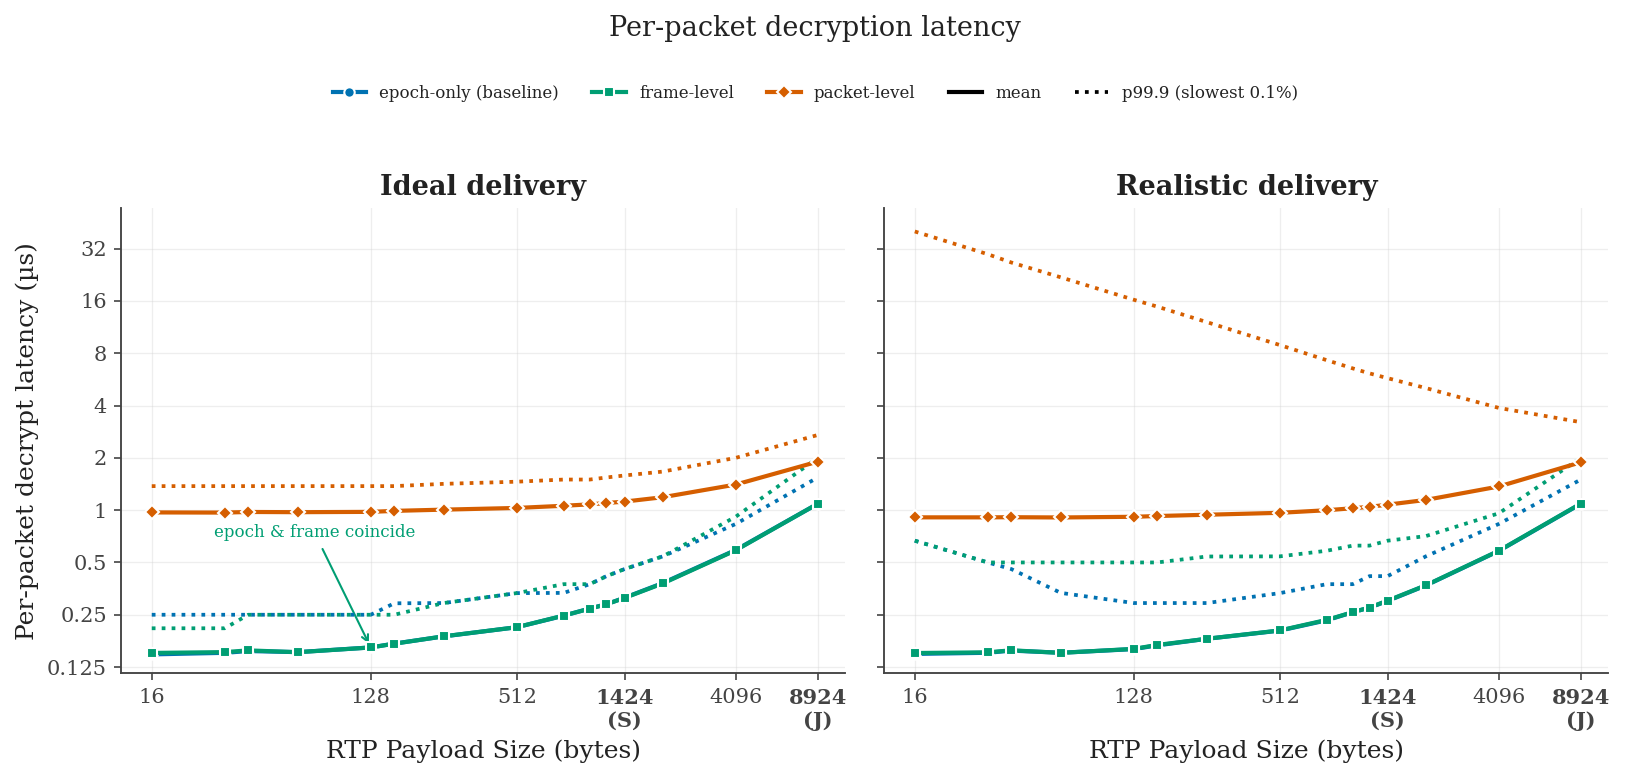

In [180]:
# --- Figure 12: realistic latency, mean (solid) and p99.9 (dotted) ---
from matplotlib.lines import Line2D

# the y ticks
Y_TICKS = [0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, cond, title in [(axes[0], 'clean', 'Ideal delivery'),
                        (axes[1], 'disturbed', 'Realistic delivery')]:
    for g in GRAN:
        st = GRAN_STYLE[g]
        ser = realistic[(g, cond)]
        xs = np.array(sorted(ser.keys()))
        mean = np.array([ser[s]['mean_ns'] for s in xs]) / 1000
        p999 = np.array([ser[s]['p999_ns'] for s in xs]) / 1000
        ax.plot(xs, mean, color=st['color'], marker=st['marker'], ls='-',
                lw=2, markersize=5, zorder=5)
        ax.plot(xs, p999, color=st['color'], ls=':', lw=1.8, zorder=4)
    _gran_style_x(ax)
    ax.set_yscale('log')
    ax.set_yticks(Y_TICKS)
    ax.set_yticklabels([f'{t:g}' for t in Y_TICKS])
    ax.yaxis.set_minor_locator(ticker.NullLocator())
    ax.set_xlabel('RTP Payload Size (bytes)')
    ax.set_title(title)
    ax.set_xlim(12, 8924 * 1.3)
    ax.set_ylim(0.115, 55)

axes[0].set_ylabel('Per-packet decrypt latency (µs)')

# "epoch & frame coincide" label
# the epoch line is invisible without this, as frame sits exactly on top of it
axes[0].annotate('epoch & frame coincide',
                 xy=(128, realistic[('epoch', 'clean')][128]['mean_ns'] / 1000),
                 xytext=(75, 0.7), fontsize=8, ha='center', color='#009E73',
                 arrowprops=dict(arrowstyle='->', color='#009E73', lw=1))

# one legend row above both panels: color says the granularity, line style
# says which statistic the line shows
handles = [Line2D([], [], color=GRAN_STYLE[g]['color'], marker=GRAN_STYLE[g]['marker'],
                  ls='-', lw=2, markersize=5, label=GRAN_STYLE[g]['label']) for g in GRAN]
handles += [Line2D([], [], color='black', ls='-', lw=2, label='mean'),
            Line2D([], [], color='black', ls=':', lw=1.8, label='p99.9 (slowest 0.1%)')]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncols=5,
           fontsize=8, frameon=False)

fig.suptitle('Per-packet decryption latency', y=1.12, fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig12_realistic_latency.pdf')
plt.savefig(FIGURES_DIR / 'fig12_realistic_latency.png')
plt.show()

## Figure 13: Keying Loss vs. Key Window K

The K tradeoff at the standard 1424 B MTU under the disturbed network: of the
packets the network delivered, the fraction the receiver dropped because their
key was already deleted.

The packet-level curve has three regions. Below K=24 the jitter
reordering (up to ~21 positions) is no longer covered and loss explodes. From
K=24 to 448 only the 100 path-B rescue copies are lost (each arrives ~437
positions late, more than any K in that range). Hence, we get a plateau at
0.01% (100 packets of the million). From K=456 loss is zero: the worst packet
of the run arrives 455 positions late, and holding its key plus the newest
one takes 456 slots. K counts keys at both granularities. However, what one key
covers differs (a packet at packet level, a whole frame at frame level),
which is why frame-level needs so few. Frame-level is loss-free from K=2 on, 
because a late packet here never spans more than one frame boundary.

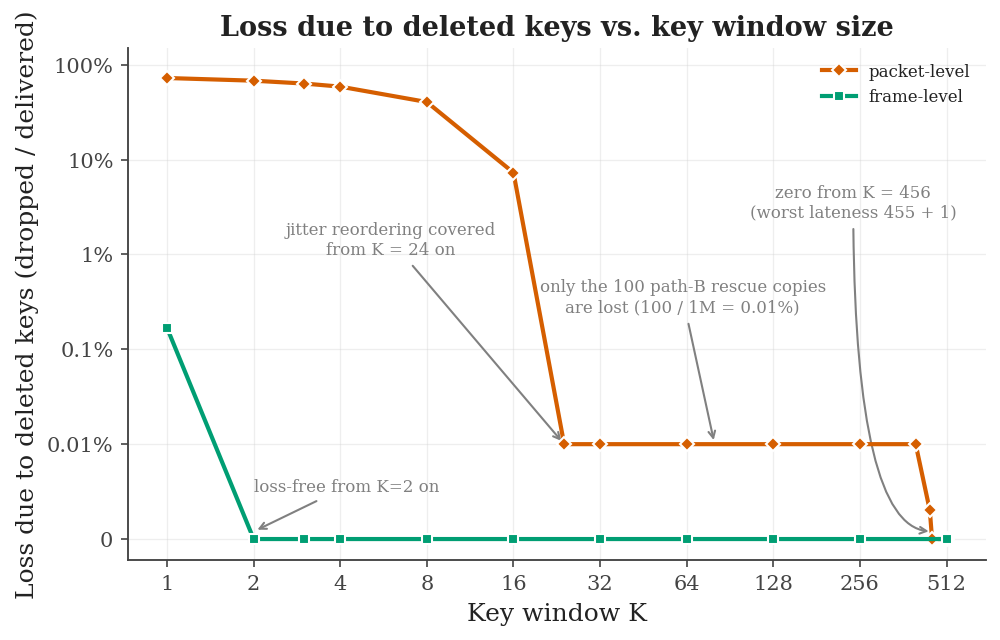

In [181]:
# --- Figure 13: keying loss vs K ---

# a log axis cannot show 0
FLOOR = 1e-5

fig, ax = plt.subplots(figsize=(6.8, 4.4))

# the two curves: for each K sweep, the K values sorted ascending on x,
# their loss rates on y, with zeros lifted onto the FLOOR line
for series, st, lab in [(k_packet, GRAN_STYLE['packet'], 'packet-level'),
                        (k_frame, GRAN_STYLE['frame'], 'frame-level')]:
    ks = np.array(sorted(series.keys()))
    ys = np.maximum(np.array([series[k] for k in ks]), FLOOR)
    ax.plot(ks, ys, color=st['color'], marker=st['marker'], ls='-',
            lw=2, markersize=5, zorder=5, label=lab)

# both axes logarithmic: x doubles per step (K spans 1..512), y covers
# loss rates from 72% (K=1) down to 0.002% (K=448), with the FLOOR tick labeled 0
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_ylim(6e-6, 1.5)
ax.set_yticks([FLOOR, 1e-4, 1e-3, 1e-2, 1e-1, 1])
ax.set_yticklabels(['0', '0.01%', '0.1%', '1%', '10%', '100%'])
# remove the small automatic sub-decade tick marks (0.2, 0.3, ...)
ax.yaxis.set_minor_locator(ticker.NullLocator())

# region 1 ends here: K=24 is the first K that covers the everyday
# jitter reordering (packets arrive at most ~21 positions late)
ax.annotate('jitter reordering covered\nfrom K = 24 on', xy=(24, 1e-4), xytext=(6, 1e-2),
            fontsize=8, color='gray', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))
# region 2: the plateau, the 100 path-B rescues out of 1M packets
ax.annotate('only the 100 path-B rescue copies\nare lost (100 / 1M = 0.01%)', xy=(80, 1e-4),
            xytext=(62, 2.5e-3), fontsize=8, color='gray', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))
# region 3: zero loss once K exceeds the worst measured lateness
ax.annotate('zero from K = 456\n(worst lateness 455 + 1)', xy=(459, 1.2e-5),
            xytext=(555, 2.5e-2), fontsize=8, color='gray', ha='right',
            multialignment='center',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1,
                            connectionstyle='angle3,angleA=-90,angleB=0'))
# the frame-level curve is loss-free from K=2 on
ax.annotate('loss-free from K=2 on', xy=(2, 1.2e-5), xytext=(2, 3.2e-5),
            fontsize=8, color='gray', ha='left',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128, 256, 512])
ax.set_xticklabels(['1', '2', '4', '8', '16', '32', '64', '128', '256', '512'])
ax.set_xlabel('Key window K')
ax.set_ylabel('Loss due to deleted keys (dropped / delivered)')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Loss due to deleted keys vs. key window size')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig13_keying_loss.pdf')
plt.savefig(FIGURES_DIR / 'fig13_keying_loss.png')
plt.show()

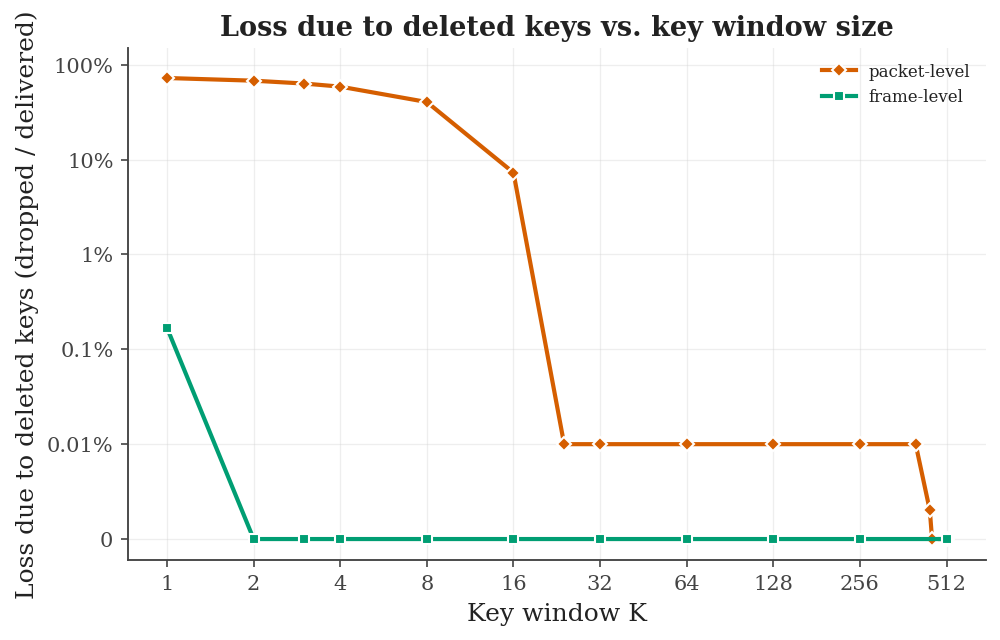

In [182]:
# --- Figure 13 without annotations ---
# Same plot as above but without the explanation texts.

fig, ax = plt.subplots(figsize=(6.8, 4.4))

for series, st, lab in [(k_packet, GRAN_STYLE['packet'], 'packet-level'),
                        (k_frame, GRAN_STYLE['frame'], 'frame-level')]:
    ks = np.array(sorted(series.keys()))
    ys = np.maximum(np.array([series[k] for k in ks]), FLOOR)
    ax.plot(ks, ys, color=st['color'], marker=st['marker'], ls='-',
            lw=2, markersize=5, zorder=5, label=lab)

ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_ylim(6e-6, 1.5)
ax.set_yticks([FLOOR, 1e-4, 1e-3, 1e-2, 1e-1, 1])
ax.set_yticklabels(['0', '0.01%', '0.1%', '1%', '10%', '100%'])
ax.yaxis.set_minor_locator(ticker.NullLocator())

ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128, 256, 512])
ax.set_xticklabels(['1', '2', '4', '8', '16', '32', '64', '128', '256', '512'])
ax.set_xlabel('Key window K')
ax.set_ylabel('Loss due to deleted keys (dropped / delivered)')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Loss due to deleted keys vs. key window size')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig13_keying_loss_clean.pdf')
plt.savefig(FIGURES_DIR / 'fig13_keying_loss_clean.png')
plt.show()


## Figure 14: Keys vs. Exposure Across Keying Granularities

Each point is one rekeying interval N, from per-packet to per-frame: 
the keys the receiver must keep for zero loss, the media those keys
unlock together, and the measured decryption throughput.

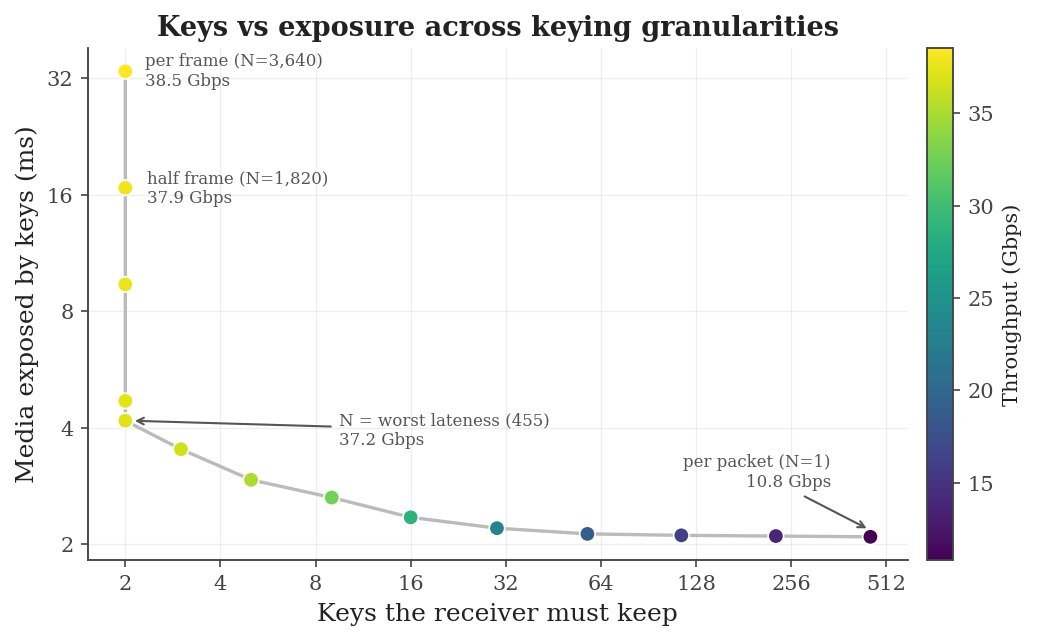

In [183]:
# --- Figure 14: keys-vs-exposure tradeoff across granularities ---

base = realistic[('packet', 'disturbed')][1424]
L = int(base['lateness_max'])
spacing_ms = base['spacing_ns'] / 1e6
PPF = int(base['ppf'])

# measured throughput per N
n_gbps = {int(r['granularity'].removeprefix('every')): r['gbps']
          for r in raw_rows if r['group'] == 'n_sweep'}
n_gbps[1] = realistic[('packet', 'disturbed')][1424]['gbps']
n_gbps[PPF] = realistic[('frame', 'disturbed')][1424]['gbps']
gbps = lambda N: n_gbps[N]

Ns = [1, 2, 4, 8, 16, 32, 64, 128, 256, L, 512, 1024, PPF // 2, PPF]

# ceil(L/N) + 1 keys for zero loss
keys = [(-(-L // N)) + 1 for N in Ns]
exposure_ms = [k * N * spacing_ms for k, N in zip(keys, Ns)]

fig, ax = plt.subplots(figsize=(7.4, 4.4))

th = [gbps(N) for N in Ns]
ax.plot(keys, exposure_ms, color='#bbb', lw=1.6, zorder=2)
sc = ax.scatter(keys, exposure_ms, c=th, cmap='viridis', s=55, zorder=4,
                edgecolors='white', linewidths=0.8)
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Throughput (Gbps)', fontsize=10)

ax.annotate(f'per packet (N=1)\n{gbps(1):.1f} Gbps', xy=(keys[0], exposure_ms[0] * 1.04),
            xytext=(keys[0] * 0.75, exposure_ms[0] * 1.35), fontsize=8, ha='right',
            color='#555', arrowprops=dict(arrowstyle='->', color='#555', lw=1))
ax.annotate(f'per frame (N=3,640)\n{gbps(PPF):.1f} Gbps', xy=(keys[-1], exposure_ms[-1]),
            xytext=(keys[-1] * 1.15, exposure_ms[-1]), fontsize=8, va='center',
            color='#555')
ax.annotate(f'half frame (N=1,820)\n{gbps(PPF // 2):.1f} Gbps', xy=(2, PPF * spacing_ms), xytext=(2.35, PPF * spacing_ms),
            fontsize=8, va='center', color='#555')
ax.annotate(f'N = worst lateness (455)\n{gbps(L):.1f} Gbps',
            xy=(2.08, 2 * L * spacing_ms), xytext=(9.5, 4.4),
            fontsize=8, va='top', color='#555',
            arrowprops=dict(arrowstyle='->', color='#555', lw=1))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([2, 4, 8, 16, 32, 64, 128, 256, 512])
ax.set_xticklabels(['2', '4', '8', '16', '32', '64', '128', '256', '512'])
ax.set_yticks([2, 4, 8, 16, 32])
ax.set_yticklabels(['2', '4', '8', '16', '32'])
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_xlabel('Keys the receiver must keep')
ax.set_ylabel('Media exposed by keys (ms)')
ax.set_title('Keys vs exposure across keying granularities')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig14_fs_tradeoff.pdf')
plt.savefig(FIGURES_DIR / 'fig14_fs_tradeoff.png')
plt.show()

## Figure 15: The Costs of the Rekeying Interval

One key covers N consecutive packets. The x-axis covers N from per-packet
to per-frame. 

Blue, left axis: keys the receiver must keep for
zero loss, ceil(455/N) + 1 given the worst measured lateness of 455
packets. 

Red, right axis: the media those keys unlock together, key count
x N packets. Finer keying piles up keys (and results in lower throughput), coarser
keying exposes more media.

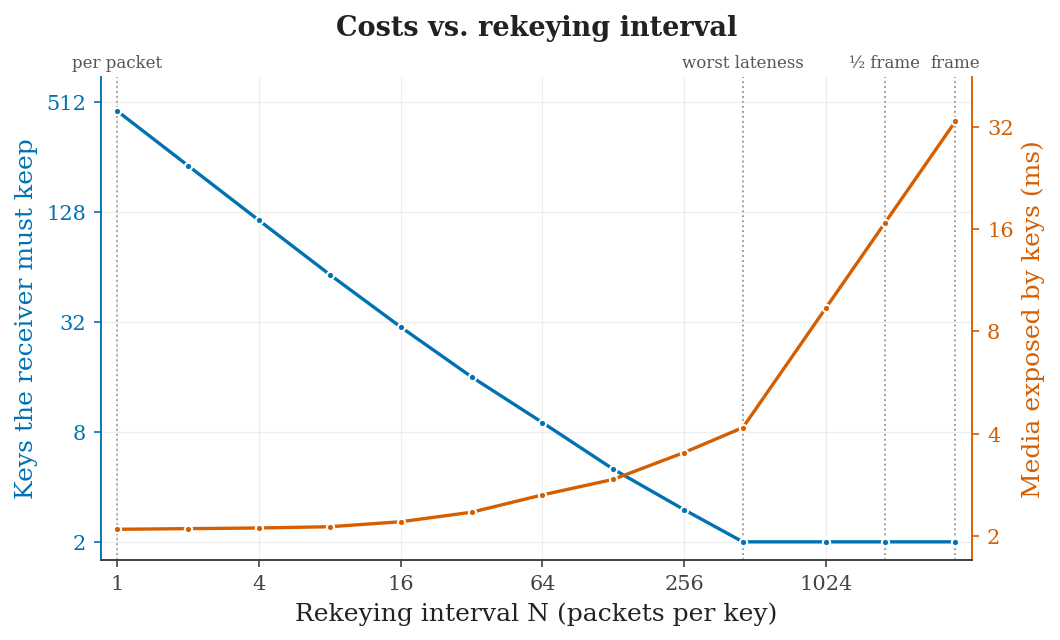

In [184]:
# --- Figure 15: keys and exposure vs N ---

# the three base values
base = realistic[('packet', 'disturbed')][1424]
L = int(base['lateness_max'])
spacing_ms = base['spacing_ns'] / 1e6
PPF = int(base['ppf'])

# the measured intervals
n_gbps = {int(r['granularity'].removeprefix('every')): r['gbps']
          for r in raw_rows if r['group'] == 'n_sweep'}
n_gbps[1] = base['gbps']
n_gbps[PPF] = realistic[('frame', 'disturbed')][1424]['gbps']
Ns = [N for N in sorted(n_gbps) if N != 512]

# the two consequences of each N: keys needed for zero loss and the media
# they unlock together
keys = [(-(-L // N)) + 1 for N in Ns]
exposure_ms = [k * N * spacing_ms for k, N in zip(keys, Ns)]

BLUE, RED = '#0072B2', '#D55E00'

fig, axK = plt.subplots(figsize=(7.2, 4.4))
axE = axK.twinx()

# the two cost curves, one per y axis
axK.plot(Ns, keys, color=BLUE, lw=1.6, marker='o', markersize=3.5, zorder=3)
axE.plot(Ns, exposure_ms, color=RED, lw=1.6, marker='o', markersize=3.5, zorder=3)

for N, name in [(1, 'per packet'), (L, 'worst lateness'),
                (PPF // 2, '½ frame'), (PPF, 'frame')]:
    axK.axvline(N, color='#999', lw=0.9, ls=':', zorder=1)
    axK.text(N, 1.02, name, fontsize=8, ha='center', color='#555',
             transform=axK.get_xaxis_transform())

axK.set_xscale('log')
axK.set_xticks([1, 4, 16, 64, 256, 1024])
axK.set_xticklabels(['1', '4', '16', '64', '256', '1024'])
axK.xaxis.set_minor_locator(ticker.NullLocator())
axK.set_xlim(0.85, 4300)
axK.set_xlabel('Rekeying interval N (packets per key)')

axK.set_yscale('log')
axK.set_yticks([2, 8, 32, 128, 512])
axK.set_yticklabels(['2', '8', '32', '128', '512'])
axK.yaxis.set_minor_locator(ticker.NullLocator())
axK.set_ylim(1.6, 700)
axK.set_ylabel('Keys the receiver must keep', color=BLUE)
axK.tick_params(axis='y', colors=BLUE)
axK.spines['left'].set_color(BLUE)

axE.set_yscale('log')
axE.set_yticks([2, 4, 8, 16, 32])
axE.set_yticklabels(['2', '4', '8', '16', '32'])
axE.yaxis.set_minor_locator(ticker.NullLocator())
axE.set_ylim(1.7, 45)
axE.set_ylabel('Media exposed by keys (ms)', color=RED)
axE.tick_params(axis='y', colors=RED)
axE.spines['right'].set_visible(True)
axE.spines['right'].set_color(RED)
axE.grid(False)
axE.spines['left'].set_visible(False)

axK.set_title('Costs vs. rekeying interval', pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig15_fs_tradeoff_vs_n.pdf')
plt.savefig(FIGURES_DIR / 'fig15_fs_tradeoff_vs_n.png')
plt.show()

## Figure 16: Keys vs. Throughput Across the Rekeying Interval

Same as above, but showing the throughput instead of the media exposed 
(that part is covered by putting the formula in the figure).

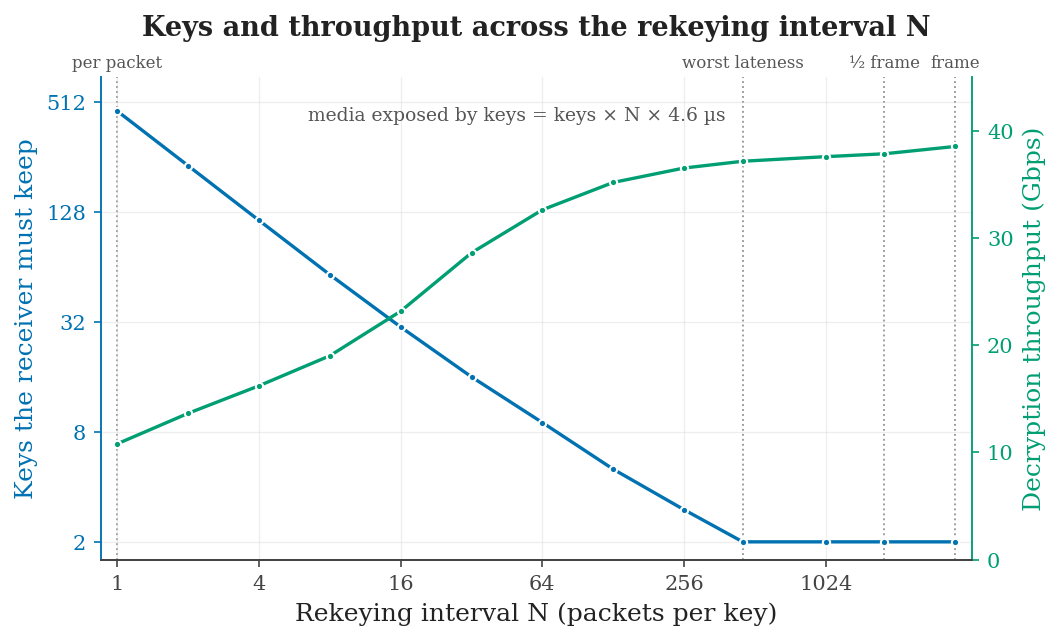

In [185]:
# --- Figure 16: keys and throughput vs N, exposure put as a formula ---

# the three base values
base = realistic[('packet', 'disturbed')][1424]
L = int(base['lateness_max'])
spacing_us = base['spacing_ns'] / 1e3
PPF = int(base['ppf'])

# the measured intervals
n_gbps = {int(r['granularity'].removeprefix('every')): r['gbps']
          for r in raw_rows if r['group'] == 'n_sweep'}
n_gbps[1] = base['gbps']
n_gbps[PPF] = realistic[('frame', 'disturbed')][1424]['gbps']
Ns = [N for N in sorted(n_gbps) if N != 512]

keys = [(-(-L // N)) + 1 for N in Ns]
th = [n_gbps[N] for N in Ns]

BLUE, GREEN = '#0072B2', '#009E73'

fig, axK = plt.subplots(figsize=(7.2, 4.4))
axT = axK.twinx()

# the storage cost and the performance payoff, one per y axis
axK.plot(Ns, keys, color=BLUE, lw=1.6, marker='o', markersize=3.5, zorder=3)
axT.plot(Ns, th, color=GREEN, lw=1.6, marker='o', markersize=3.5, zorder=3)

axK.text(50, 0.91,
         f'media exposed by keys = keys × N × {spacing_us:.1f} µs',
         fontsize=9, color='#555', ha='center',
         transform=axK.get_xaxis_transform())

for N, name in [(1, 'per packet'), (L, 'worst lateness'),
                (PPF // 2, '½ frame'), (PPF, 'frame')]:
    axK.axvline(N, color='#999', lw=0.9, ls=':', zorder=1)
    axK.text(N, 1.02, name, fontsize=8, ha='center', color='#555',
             transform=axK.get_xaxis_transform())

axK.set_xscale('log')
axK.set_xticks([1, 4, 16, 64, 256, 1024])
axK.set_xticklabels(['1', '4', '16', '64', '256', '1024'])
axK.xaxis.set_minor_locator(ticker.NullLocator())
axK.set_xlim(0.85, 4300)
axK.set_xlabel('Rekeying interval N (packets per key)')

axK.set_yscale('log')
axK.set_yticks([2, 8, 32, 128, 512])
axK.set_yticklabels(['2', '8', '32', '128', '512'])
axK.yaxis.set_minor_locator(ticker.NullLocator())
axK.set_ylim(1.6, 700)
axK.set_ylabel('Keys the receiver must keep', color=BLUE)
axK.tick_params(axis='y', colors=BLUE)
axK.spines['left'].set_color(BLUE)

axT.set_ylim(0, 45)
axT.set_yticks([0, 10, 20, 30, 40])
axT.set_ylabel('Decryption throughput (Gbps)', color=GREEN)
axT.tick_params(axis='y', colors=GREEN)
axT.spines['right'].set_visible(True)
axT.spines['right'].set_color(GREEN)
axT.grid(False)
axT.spines['left'].set_visible(False)

axK.set_title('Keys and throughput across the rekeying interval N', pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig16_keys_throughput_vs_n.pdf')
plt.savefig(FIGURES_DIR / 'fig16_keys_throughput_vs_n.png')
plt.show()

## Figure 17: Exposure vs. Throughput Across the Rekeying Interval

The complementary view to Figure 16: media exposed by the kept keys (blue,
left axis) and decryption throughput (green, right axis).

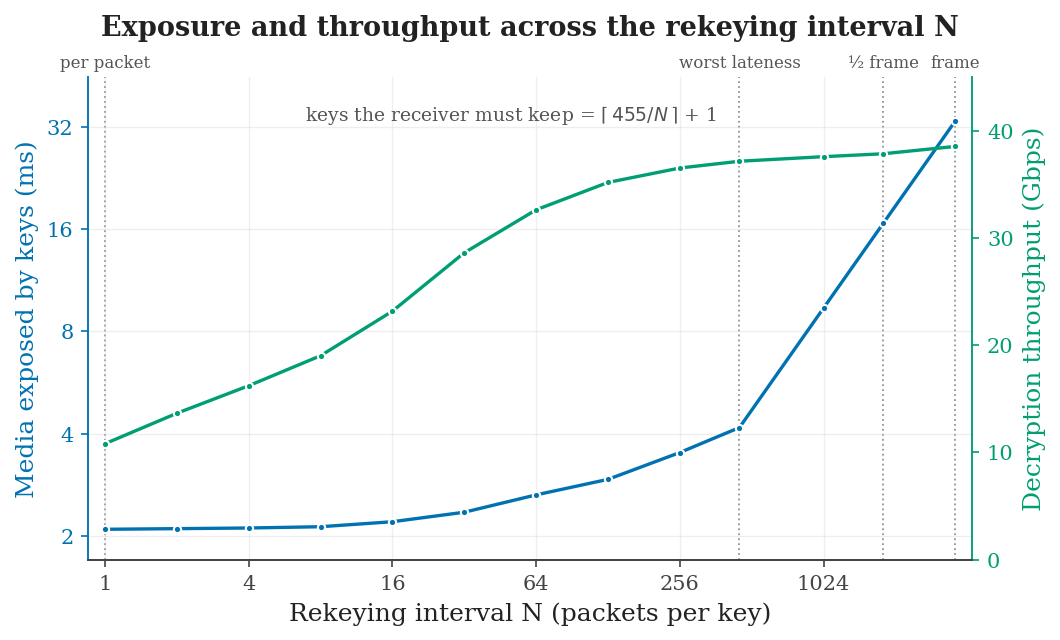

In [186]:
# --- Figure 17: exposure and throughput vs N, keys stated as a formula ---

# the three base values
base = realistic[('packet', 'disturbed')][1424]
L = int(base['lateness_max'])
spacing_ms = base['spacing_ns'] / 1e6
PPF = int(base['ppf'])

# the measured intervals
n_gbps = {int(r['granularity'].removeprefix('every')): r['gbps']
          for r in raw_rows if r['group'] == 'n_sweep'}
n_gbps[1] = base['gbps']
n_gbps[PPF] = realistic[('frame', 'disturbed')][1424]['gbps']
Ns = [N for N in sorted(n_gbps) if N != 512]

keys = [(-(-L // N)) + 1 for N in Ns]
exposure_ms = [k * N * spacing_ms for k, N in zip(keys, Ns)]
th = [n_gbps[N] for N in Ns]

BLUE, GREEN = '#0072B2', '#009E73'

fig, axE = plt.subplots(figsize=(7.2, 4.4))
axT = axE.twinx()

# the security cost and the performance payoff, one per y axis
axE.plot(Ns, exposure_ms, color=BLUE, lw=1.6, marker='o', markersize=3.5, zorder=3)
axT.plot(Ns, th, color=GREEN, lw=1.6, marker='o', markersize=3.5, zorder=3)

axE.text(50, 0.91,
         f'keys the receiver must keep = $\\lceil\\, {L} / N \\,\\rceil$ + 1',
         fontsize=9, color='#555', ha='center',
         transform=axE.get_xaxis_transform())

for N, name in [(1, 'per packet'), (L, 'worst lateness'),
                (PPF // 2, '½ frame'), (PPF, 'frame')]:
    axE.axvline(N, color='#999', lw=0.9, ls=':', zorder=1)
    axE.text(N, 1.02, name, fontsize=8, ha='center', color='#555',
             transform=axE.get_xaxis_transform())

axE.set_xscale('log')
axE.set_xticks([1, 4, 16, 64, 256, 1024])
axE.set_xticklabels(['1', '4', '16', '64', '256', '1024'])
axE.xaxis.set_minor_locator(ticker.NullLocator())
axE.set_xlim(0.85, 4300)
axE.set_xlabel('Rekeying interval N (packets per key)')

axE.set_yscale('log')
axE.set_yticks([2, 4, 8, 16, 32])
axE.set_yticklabels(['2', '4', '8', '16', '32'])
axE.yaxis.set_minor_locator(ticker.NullLocator())
axE.set_ylim(1.7, 45)
axE.set_ylabel('Media exposed by keys (ms)', color=BLUE)
axE.tick_params(axis='y', colors=BLUE)
axE.spines['left'].set_color(BLUE)

axT.set_ylim(0, 45)
axT.set_yticks([0, 10, 20, 30, 40])
axT.set_ylabel('Decryption throughput (Gbps)', color=GREEN)
axT.tick_params(axis='y', colors=GREEN)
axT.spines['right'].set_visible(True)
axT.spines['right'].set_color(GREEN)
axT.grid(False)
axT.spines['left'].set_visible(False)

axE.set_title('Exposure and throughput across the rekeying interval N', pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig17_exposure_throughput_vs_n.pdf')
plt.savefig(FIGURES_DIR / 'fig17_exposure_throughput_vs_n.png')
plt.show()

## Figure 18: TESLA Authentication Throughput

What per-sender authentication (TESLA) costs on top of plain SRTP:
throughput with and without the TESLA layer, for each of its two MAC
algorithms, on both sides of the wire. 

Data from
`benches/results/tesla_throughput/raw.csv` (`cargo bench --bench tesla_throughput`).

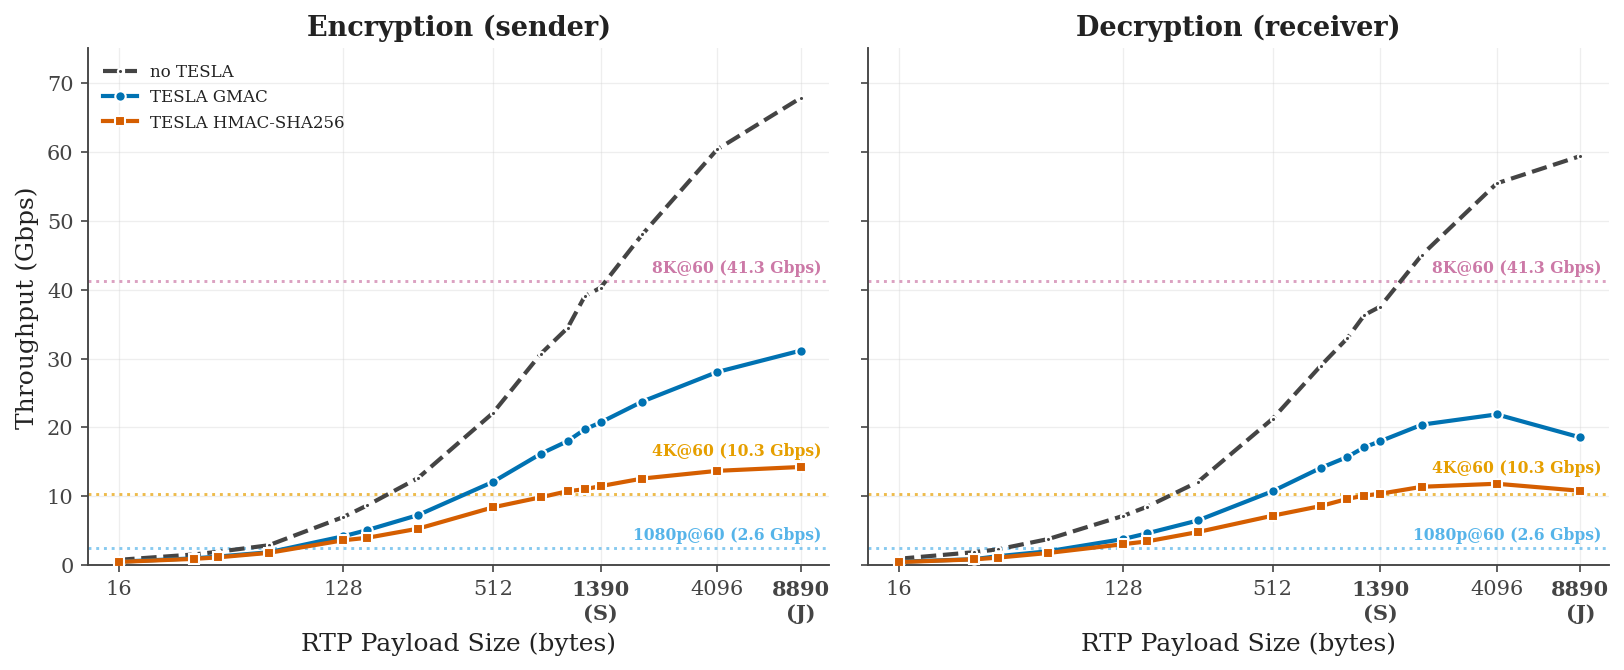

In [190]:
# --- Figure 18: TESLA authentication throughput ---
import csv

# one row per measured variant: tesla[(side, mac)][payload] = Gbit/s
TESLA_CSV = Path('benches/results/tesla_throughput/raw.csv')
tesla = {}
with open(TESLA_CSV) as f:
    for r in csv.DictReader(f):
        tesla.setdefault((r['side'], r['mac']), {})[int(r['payload'])] = float(r['gbps'])

# the three lines per panel: no TESLA (the baseline), and TESLA under
# each MAC algorithm
TESLA_LINES = [
    ('none', 'no TESLA',          '#444444', '--', '.'),
    ('gmac', 'TESLA GMAC',        '#0072B2', '-',  'o'),
    ('hmac', 'TESLA HMAC-SHA256', '#D55E00', '-',  's'),
]

# the payload x-axis, as in fig9/fig11 but with the TESLA-safe MTU
# anchors: TESLA appends a 34-byte extension to every packet, so the
# payload must shrink by 34 bytes (1424 -> 1390, 8924 -> 8890) for the
# packet to still fit the MTU
TESLA_XT = [16, 128, 512, 1390, 4096, 8890]
TESLA_XL = ['16', '128', '512', '1390\n(S)', '4096', '8890\n(J)']

# two panels sharing the y axis: encryption left, decryption right
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, side, title in [(axes[0], 'sender', 'Encryption (sender)'),
                        (axes[1], 'receiver', 'Decryption (receiver)')]:
    for mac, label, color, ls, marker in TESLA_LINES:
        xs = np.array(sorted(tesla[(side, mac)].keys()))
        ys = np.array([tesla[(side, mac)][s] for s in xs])
        ax.plot(xs, ys, color=color, ls=ls, marker=marker,
                lw=2, markersize=5, zorder=5, label=label)

    # required-bitrate reference lines
    for name, br, col in GRAN_VIDEO:
        ax.axhline(br, color=col, ls=':', lw=1.4, alpha=0.7)
        # the 4K label needs lifting (otherwise overlaps with 
        # the bitrate text)
        offset = 0.6
        if name.startswith('4K'):
            offset = 5.0 if side == 'sender' else 2.6
        ax.text(0.99, br + offset, f'{name} ({br:.1f} Gbps)',
                transform=ax.get_yaxis_transform(), ha='right', va='bottom',
                fontsize=7.5, color=col, fontweight='bold')

    ax.set_xscale('log', base=2)
    ax.set_xticks(TESLA_XT); ax.set_xticklabels(TESLA_XL)
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    for lbl in ax.xaxis.get_ticklabels():
        if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
            lbl.set_fontweight('bold')
    ax.set_xlabel('RTP Payload Size (bytes)')
    ax.set_xlim(12, 8890 * 1.3)
    ax.set_title(title)

axes[0].set_ylabel('Throughput (Gbps)')
axes[0].set_ylim(0, 75)
axes[0].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig18_tesla_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig18_tesla_throughput.png')
plt.show()

## Figure 19: TESLA Receiver Latency and its Slowest Calls

TESLA defers verification, so its receiver-side work is unevenly distributed. Most calls just decrypt (an arriving packet's own tag cannot be
checked yet, its key is still secret), but the call that
brings a new key verifies a whole interval of waiting packets in
one burst.

solid = the mean call, dotted = the slowest 0.1% of calls (p99.9), which is where the bursts surface.

Similar to Figure 12.


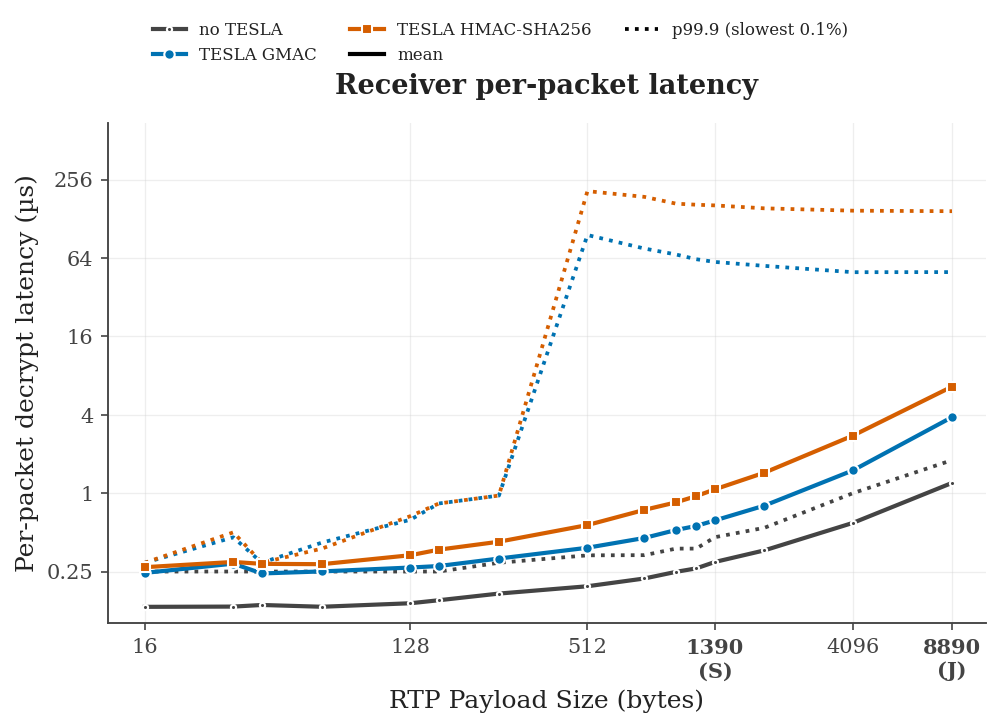

In [188]:
# --- Figure 19: receiver latency, mean (solid) and p99.9 (dotted) ---
from matplotlib.lines import Line2D

# per (mac, payload): the mean call and the p99.9, receiver side
tesla_lat = {}
with open(TESLA_CSV) as f:
    for r in csv.DictReader(f):
        if r['side'] == 'receiver':
            tesla_lat.setdefault(r['mac'], {})[int(r['payload'])] = (
                float(r['mean_ns']), float(r['p99_9_ns']))

# the y ticks (us, log scale)
Y_TICKS = [0.25, 1, 4, 16, 64, 256, 1024, 4096]

fig, ax = plt.subplots(figsize=(6.8, 4.6))
# gray = no TESLA, blue = GMAC, orange = HMAC
for mac, label, color, _ls, marker in TESLA_LINES:
    ser = tesla_lat[mac]
    xs = np.array(sorted(ser.keys()))
    mean = np.array([ser[s][0] for s in xs]) / 1000
    p999 = np.array([ser[s][1] for s in xs]) / 1000
    ax.plot(xs, mean, color=color, marker=marker, ls='-', lw=2, markersize=5, zorder=5)
    ax.plot(xs, p999, color=color, ls=':', lw=1.8, zorder=4)

ax.set_xscale('log', base=2)
ax.set_xticks(TESLA_XT); ax.set_xticklabels(TESLA_XL)
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')
ax.set_yscale('log')
ax.set_yticks(Y_TICKS)
ax.set_yticklabels([f'{t:g}' for t in Y_TICKS])
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Per-packet decrypt latency (\u00b5s)')
ax.set_xlim(12, 8890 * 1.3)
ax.set_ylim(0.1, 700)

# one legend row above the panel: color says the variant, line style says
# which statistic the line shows
handles = [Line2D([], [], color=c, marker=m, ls='-', lw=2, markersize=5, label=l)
           for _mac, l, c, _ls, m in TESLA_LINES]
handles += [Line2D([], [], color='black', ls='-', lw=2, label='mean'),
            Line2D([], [], color='black', ls=':', lw=1.8, label='p99.9 (slowest 0.1%)')]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncols=3,
           fontsize=8, frameon=False)

ax.set_title('Receiver per-packet latency', pad=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig19_tesla_tails.pdf')
plt.savefig(FIGURES_DIR / 'fig19_tesla_tails.png')
plt.show()